In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme()

In [3]:
data = {
    "delay": pd.read_csv("analysis/aug-2026-labmeeting-summary/data_delay.csv"),
    "budget": pd.read_csv("analysis/aug-2026-labmeeting-summary/data_budget.csv"),
    "curves": pd.read_csv("analysis/aug-2026-labmeeting-summary/curves.csv"),
    "noise": pd.read_csv("analysis/aug-2026-labmeeting-summary/data_noise.csv"),
    "groups": pd.read_csv("analysis/aug-2026-labmeeting-summary/data_probe_groups.csv"),
    "probe": pd.read_csv("analysis/aug-2026-labmeeting-summary/data_probe.csv"),
}
def held_out(frame: pd.DataFrame) -> pd.DataFrame:
    return frame[(frame["dataset"] == "old_eval") & frame["have_eval"]]

In [29]:
df.condition.unique()

array(['efference_old', 'encdec', 'expfm', 'expfm_2g', 'no_efference_old',
       'pgfm', 'pgfm_2g'], dtype=object)

/tmp/ipykernel_8334/1095223363.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis


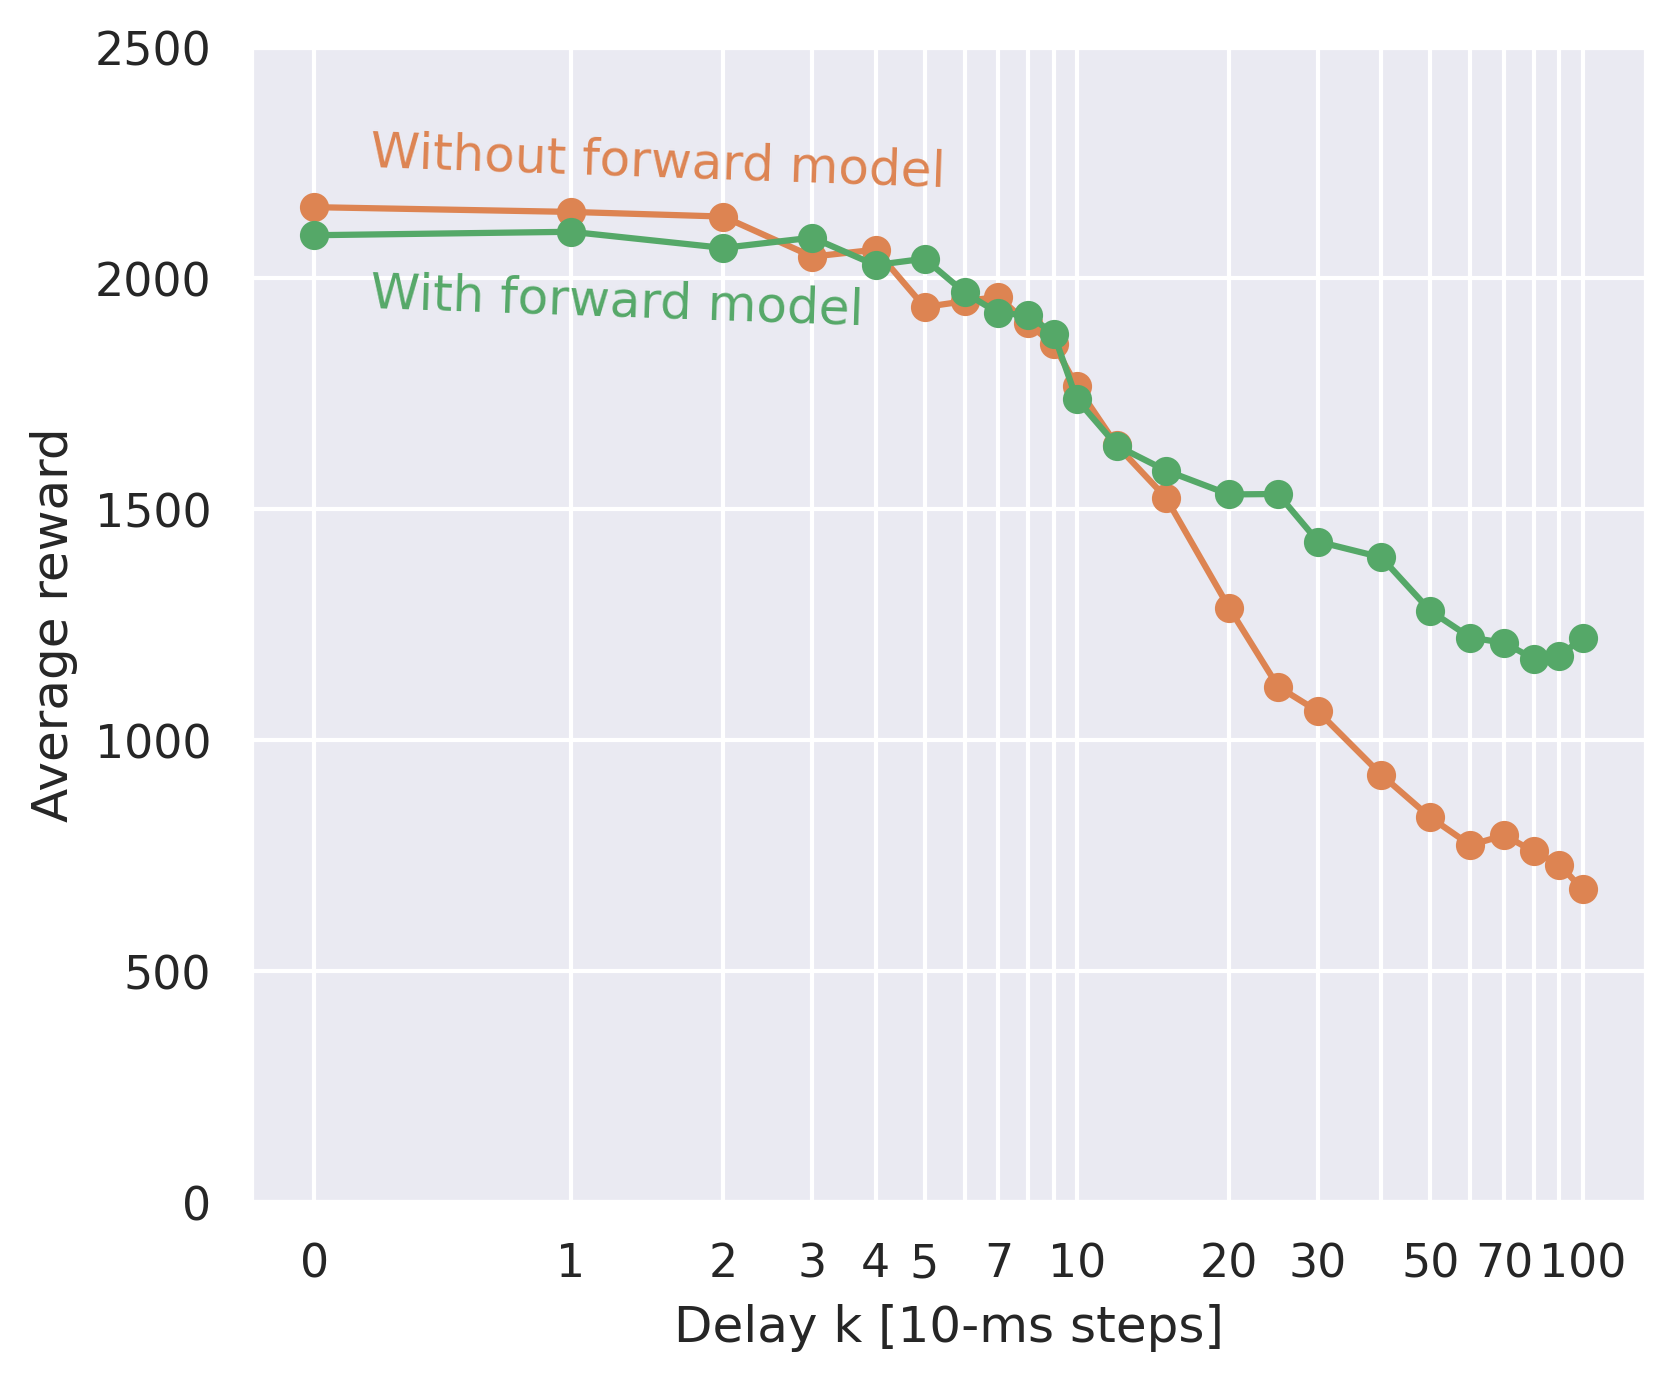

In [44]:
plt.figure(dpi=300, figsize=(6, 5))
df = held_out(data["delay"])
df.loc[df.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis

d = df[df.condition=="encdec"].groupby("delay_k").episode_reward.mean()
plt.plot(d.index, d, '-o', color="C1")

d = df[df.condition=="expfm"].groupby("delay_k").episode_reward.mean()
plt.plot(d.index, d, '-o', color="C2")

plt.gca().set_xscale("log")
plt.ylim(0, 2500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Average reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100]
plt.xticks(xticks, xticklabels)
plt.text(0.4, 2200, "Without forward model", color="C1", rotation=-2)
plt.text(0.4, 1900, "With forward model", color="C2", rotation=-2)
plt.show()

/tmp/ipykernel_8334/3821869275.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis


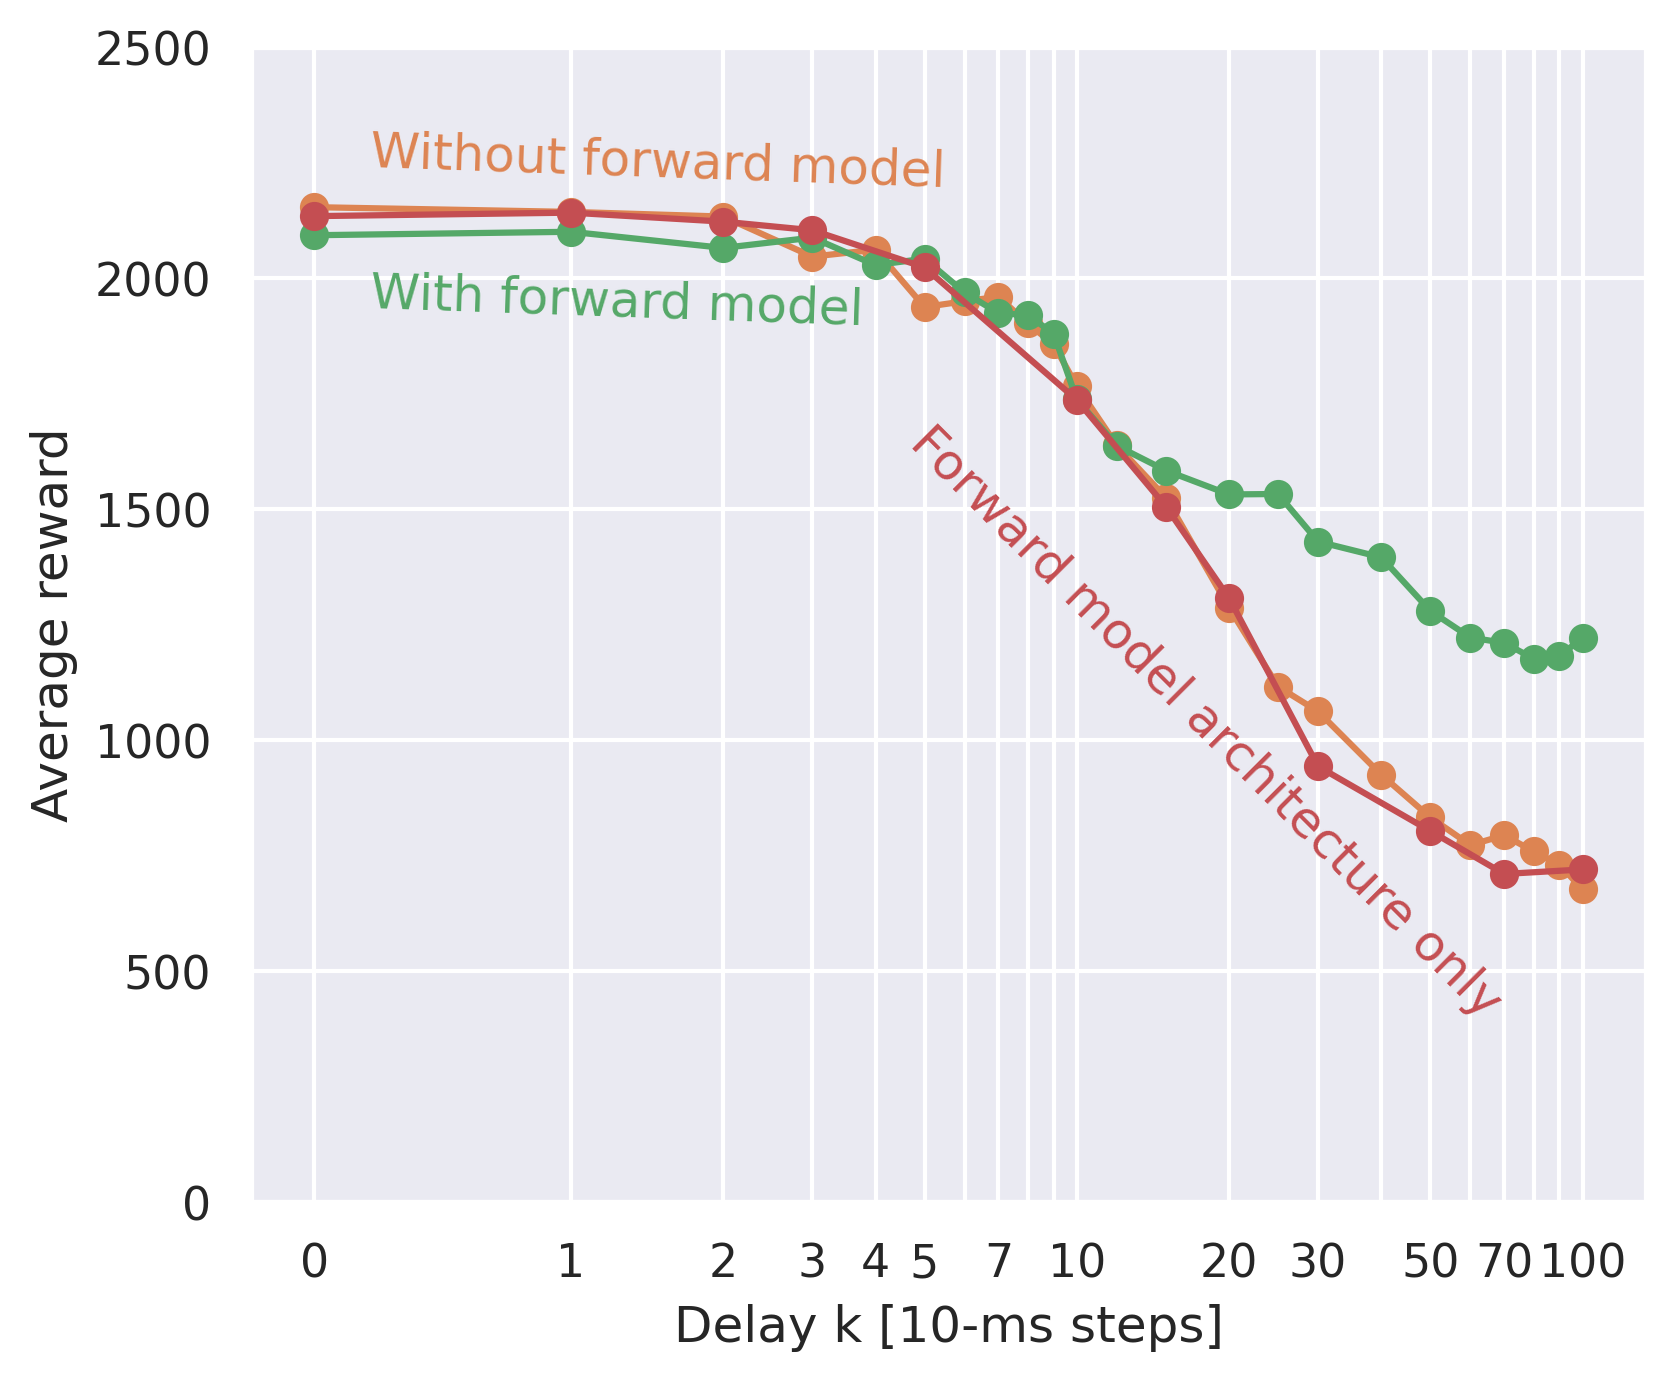

In [50]:
plt.figure(dpi=300, figsize=(6, 5))
df = held_out(data["delay"])
df.loc[df.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis

d = df[df.condition=="encdec"].groupby("delay_k").episode_reward.mean()
plt.plot(d.index, d, '-o', color="C1")

d = df[df.condition=="expfm"].groupby("delay_k").episode_reward.mean()
plt.plot(d.index, d, '-o', color="C2")

d = df[df.condition=="pgfm"].groupby("delay_k").episode_reward.mean()
plt.plot(d.index, d, '-o', color="C3")

plt.gca().set_xscale("log")
plt.ylim(0, 2500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Average reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100]
plt.xticks(xticks, xticklabels)
plt.text(0.4, 2200, "Without forward model", color="C1", rotation=-2)
plt.text(0.4, 1900, "With forward model", color="C2", rotation=-2)
plt.text(4.5, 400, "Forward model architecture only", color="C3", rotation=-45)
plt.show()

In [57]:
df.condition.unique()

array(['expfm', 'expfm_2g', 'pgfm', 'pgfm_2g'], dtype=object)

Text(700000000.0, 200, 'Default budget (600M)')

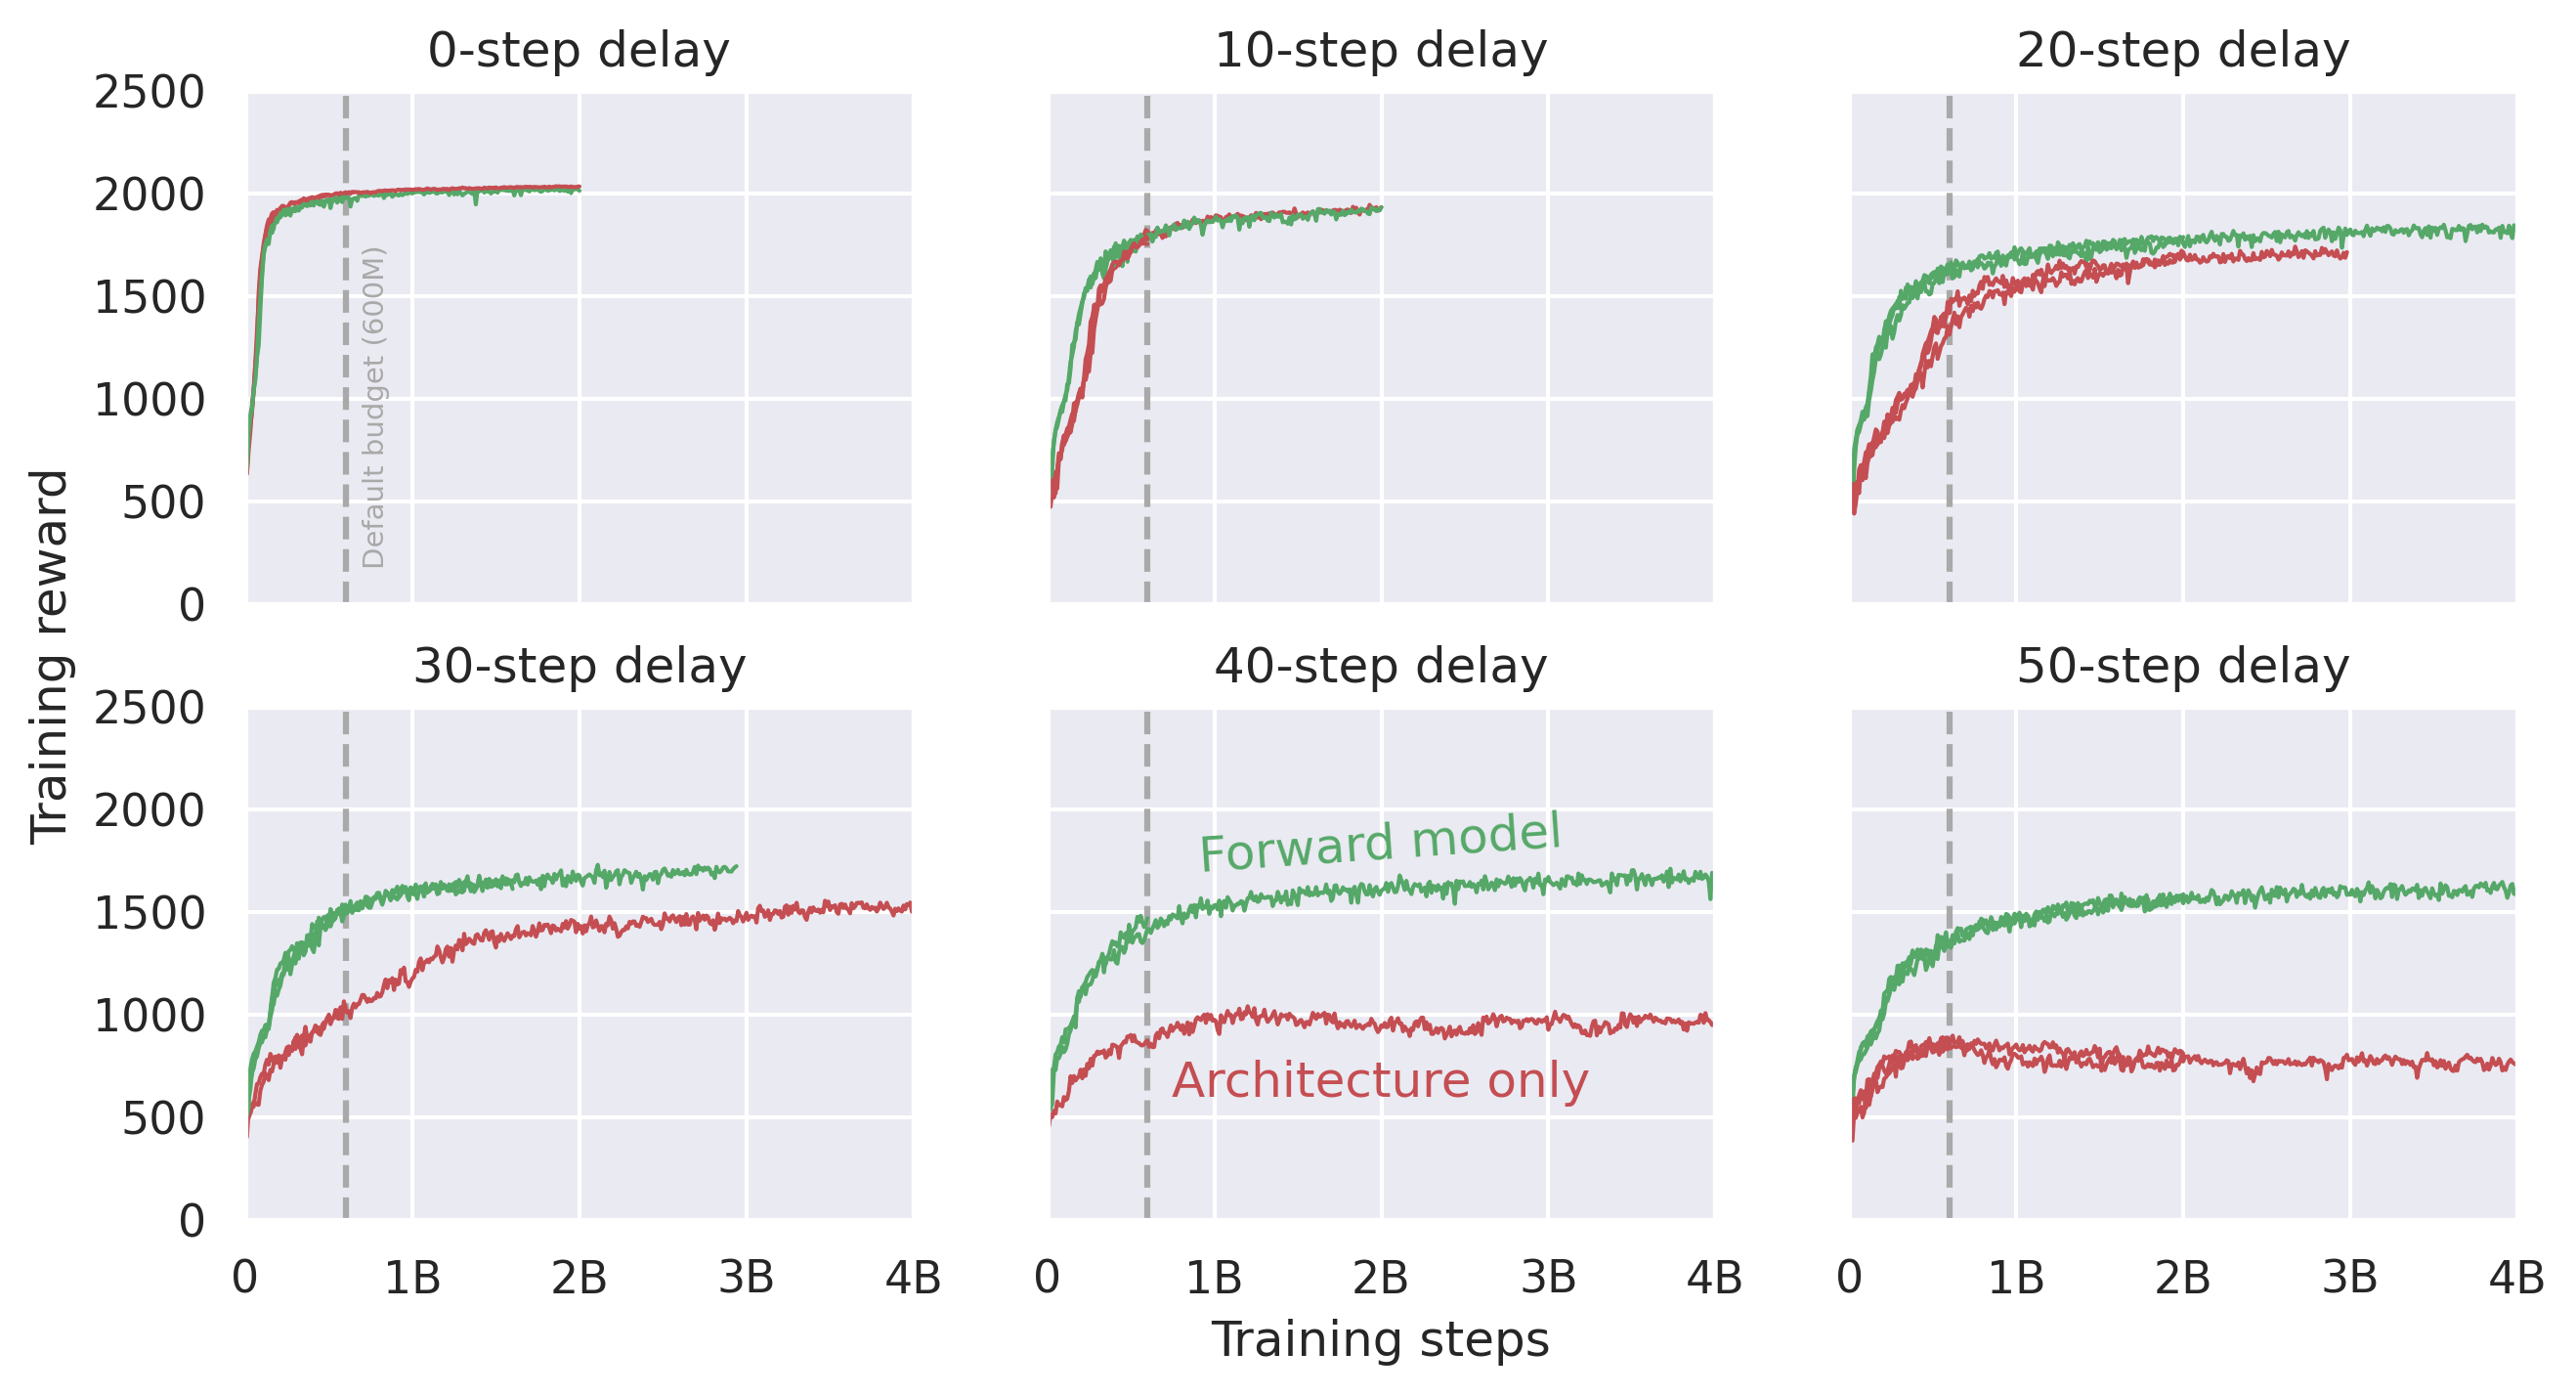

In [409]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5), sharex="col", sharey=True, dpi=300)
for ax, delay in zip(axs.flat, (0,10,20,30,40,50)):
    plt.sca(ax)
    df = data["curves"].query(f"delay_k == {delay}")
    plt.axvline(6e8, color="darkgray", ls="--")
    for _, g in df.groupby("wandb_id"):
        if g.condition.iloc[0].startswith("expfm"):
            c = "C2"
        elif g.condition.iloc[0].startswith("pgfm"):
            c = "C3"
        else:
            raise "Unknown condition:" + str(g.condition.iloc[0])
        plt.plot(g.step, g.reward_mean, color=c, lw=1, alpha=1)
    plt.xlim(0, 4e9)
    plt.ylim(0, 2500)
    plt.title(f"{delay}-step delay")
    plt.xticks((0, 1e9, 2e9, 3e9, 4e9), ("0", "1B", "2B", "3B", "4B"))
    
axs[1,1].set_xlabel("Training steps")
axs[0,0].set_ylabel("Training reward", y=-0.1)
axs[1,1].text(2e9, 1700, "Forward model", color="C2", ha="center", rotation=4)
axs[1,1].text(2e9, 600, "Architecture only", color="C3", ha="center", rotation=0)
axs[0,0].text(7e8, 200, "Default budget (600M)", color="darkgray", rotation=90, fontsize=7)

In [292]:
df = data["budget"]
collection = []
collection.append(df[df.max_step > 4e9][["delay_k", "condition", "max_step", "reward_at_4G"]].rename(columns={"reward_at_4G": "reward"}))
collection.append(df[(df.max_step < 4e9) & (df.max_step > 2.9e9)][["delay_k","condition", "max_step", "reward_at_2p9G"]].rename(columns={"reward_at_2p9G": "reward"}))
collection.append(df[(df.max_step < 2.9e9) & (df.max_step > 2e9)][["delay_k","condition", "max_step", "reward_at_2G"]].rename(columns={"reward_at_2G": "reward"}))
extra_df = pd.concat(collection)
extra_df["condition"] = df.condition.str[:4]

/tmp/ipykernel_8334/1672508141.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_8334/1672508141.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_8334/1672508141.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_833

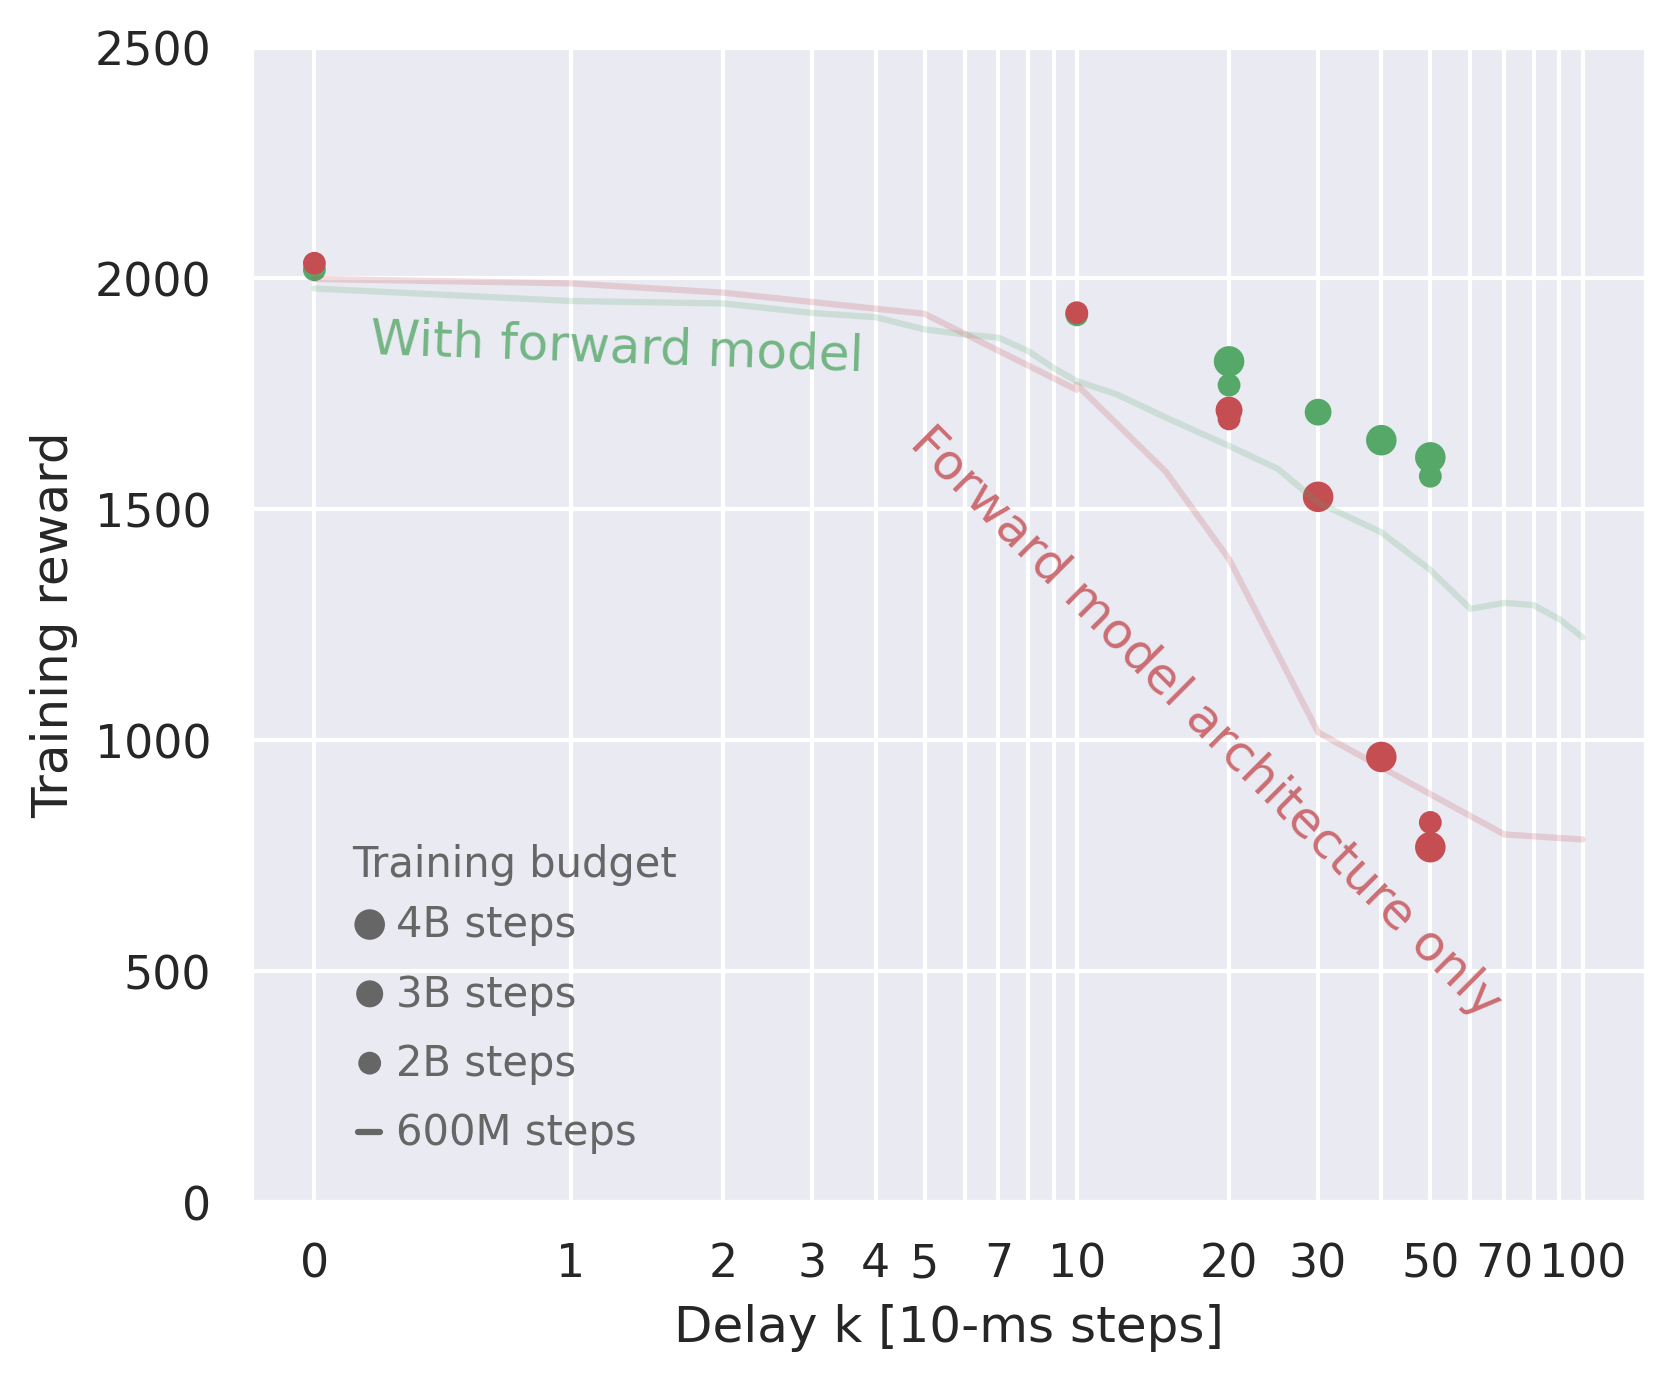

In [293]:
plt.figure(dpi=300, figsize=(6, 5))
d = df[(df.max_step==600064000) & (df.condition=="expfm")]
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
plt.semilogx(d.delay_k, d.reward_at_600M, '-', color="C2", alpha=0.2)

d = df[(df.max_step==600064000) & (df.condition=="pgfm")]
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
plt.semilogx(d.delay_k, d.reward_at_600M, '-', color="C3", alpha=0.2)

d = extra_df[(extra_df.condition=="expf")]
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
plt.scatter(d.delay_k, d.reward, s=d.max_step/1e8, color="C2")

d = extra_df[(extra_df.condition=="pgfm")]
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
plt.scatter(d.delay_k, d.reward, s=d.max_step/1e8, color="C3")

plt.scatter([0.4]*3, [300, 450, 600], s=[20,30,40], color="0.4")
plt.plot([0.38,0.42], [150, 150], color="0.4")
plt.text(0.45, 150, "600M steps", color="0.4", va="center", fontsize=10)
plt.text(0.45, 300, "2B steps", color="0.4", va="center", fontsize=10)
plt.text(0.45, 450, "3B steps", color="0.4", va="center", fontsize=10)
plt.text(0.45, 600, "4B steps", color="0.4", va="center", fontsize=10)
plt.text(0.37, 730, "Training budget", color="0.4", va="center", fontsize=10)
#edgecolor='k', color="None")

plt.ylim(0, 2500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Training reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100]
plt.xticks(xticks, xticklabels)
plt.text(0.4, 1800, "With forward model", color="C2", rotation=-2, alpha=0.8)
plt.text(4.5, 400, "Forward model architecture only", color="C3", rotation=-45, alpha=0.8)
plt.show()

In [294]:
df = data["noise"]
df = df[(df["dataset"] == "old_eval") & df["have_eval"]]

/tmp/ipykernel_8334/509185463.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_8334/509185463.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_8334/509185463.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_8334/

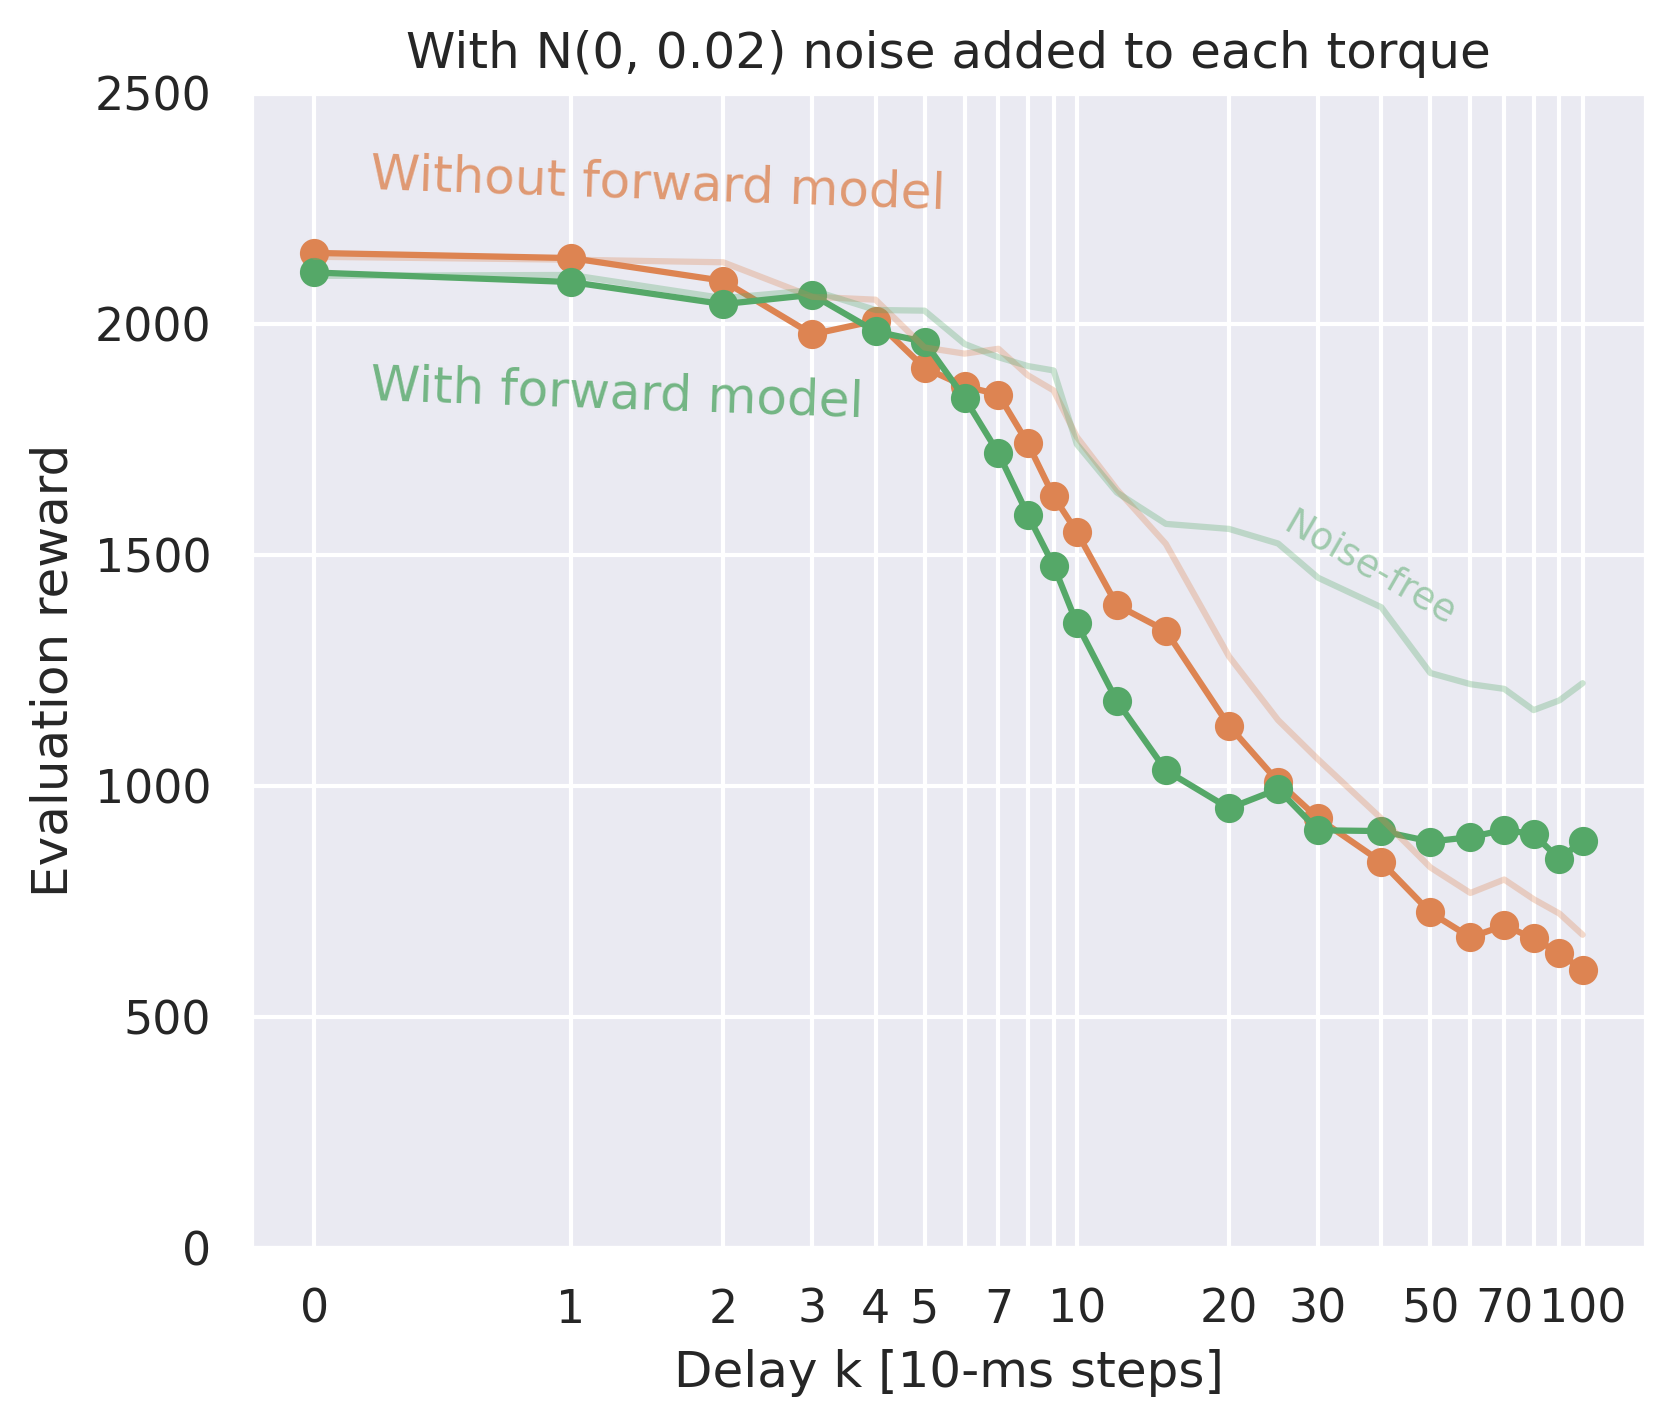

In [295]:
plt.figure(dpi=300, figsize=(6, 5))
d = df[(df.action_noise == 0.02) & (df.condition == "encdec")].copy()
d["delay_k"] = d.delay_k.astype(int)
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
d = d.sort_values("delay_k")
plt.semilogx(d.delay_k, d.episode_reward, '-o', color="C1")

d = df[(df.action_noise == 0.02) & (df.condition == "expfm")].copy()
d["delay_k"] = d.delay_k.astype(int)
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
d = d.sort_values("delay_k")
plt.semilogx(d.delay_k, d.episode_reward, '-o', color="C2")

d = df[(df.action_noise == 0.00) & (df.condition == "encdec")].copy()
d["delay_k"] = d.delay_k.astype(int)
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
d = d.sort_values("delay_k")
plt.semilogx(d.delay_k, d.episode_reward, color="C1", alpha=0.3)

d = df[(df.action_noise == 0.00) & (df.condition == "expfm")].copy()
d["delay_k"] = d.delay_k.astype(int)
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
d = d.sort_values("delay_k")
plt.semilogx(d.delay_k, d.episode_reward, color="C2", alpha=0.3)

plt.ylim(0, 2500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Evaluation reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100]
plt.xticks(xticks, xticklabels)
plt.text(0.4, 1800, "With forward model", color="C2", rotation=-2, alpha=0.8)
plt.text(0.4, 2250, "Without forward model", color="C1", rotation=-2, alpha=0.8)
plt.text(25, 1350, "Noise-free", color="C2", rotation=-30, alpha=0.5, fontsize=9)
plt.title("With N(0, 0.02) noise added to each torque")
plt.show()

Text(0.5, 1.0, '10-step delay')

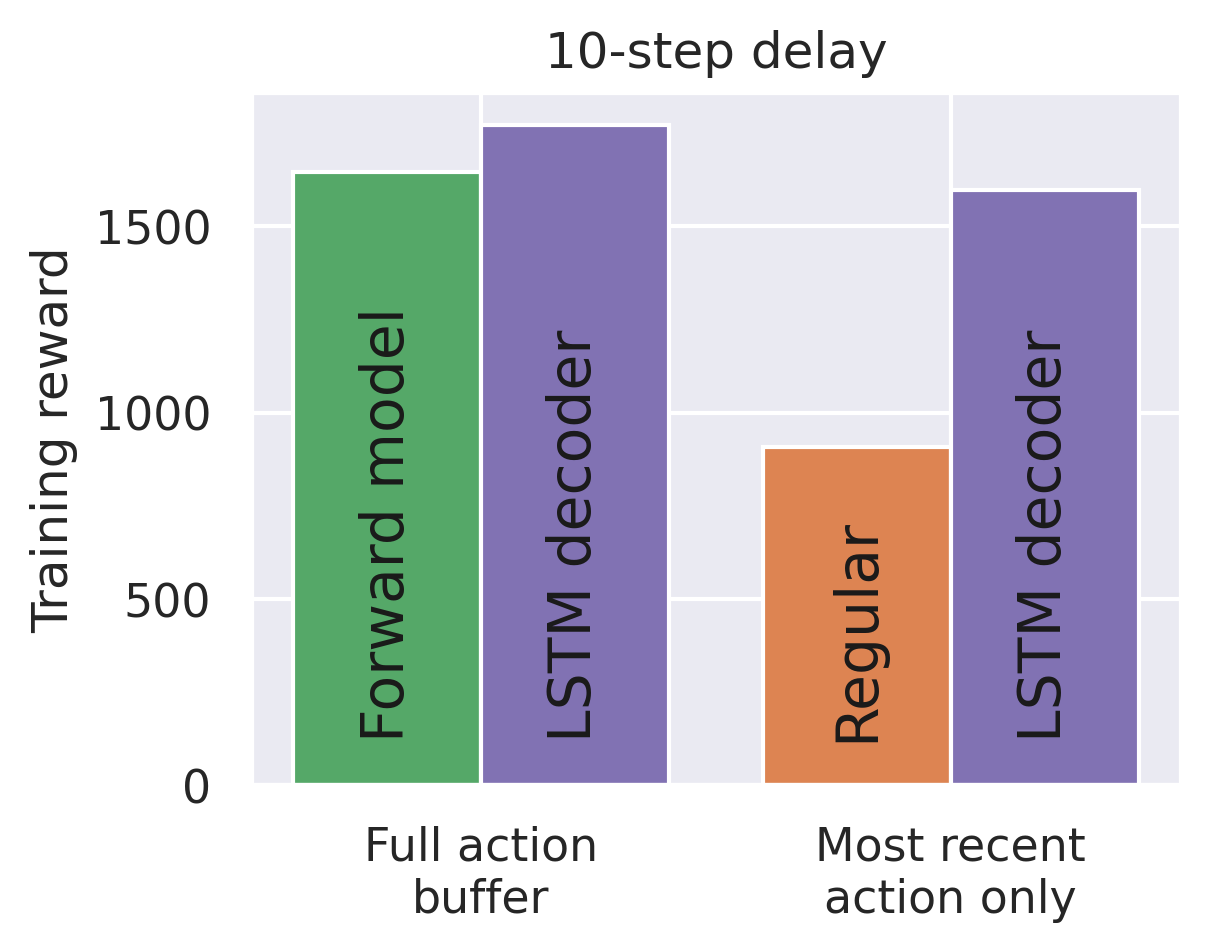

In [296]:
plt.figure(figsize=(4,3), dpi=300)
lstm_data = [
    ("forward_model", 10, 10, 1645.31396),
    ("lstm", 10, 10, 1770.55225),
    ("enc_dec", 10, 1, 906.80981),
    ("lstm", 10, 1, 1598.59937),
]
lstm_data = pd.DataFrame(lstm_data, columns=["model", "delay", "efference", "reward"])
plt.bar([0,1,2.5,3.5], lstm_data.reward, 1.0, color=["C2", "C4", "C1", "C4"])
plt.ylabel("Training reward")
plt.xticks([0.5, 3], ["Full action\nbuffer", "Most recent\naction only"])
plt.text(0, 150, "Forward model", ha="center", rotation=90, color="k", fontsize=14)
plt.text(1, 150, "LSTM decoder", ha="center", rotation=90, color="k", fontsize=14)
plt.text(2.5, 150, "Regular", ha="center", rotation=90, color="k", fontsize=14)
plt.text(3.5, 150, "LSTM decoder", ha="center", rotation=90, color="k", fontsize=14)
plt.title("10-step delay")

In [ ]:
from vnl_experiments.probes import network_diagram as nd
xs = nd.DEFAULT_DIAGRAM.tick_positions()      # the layer x coordinates

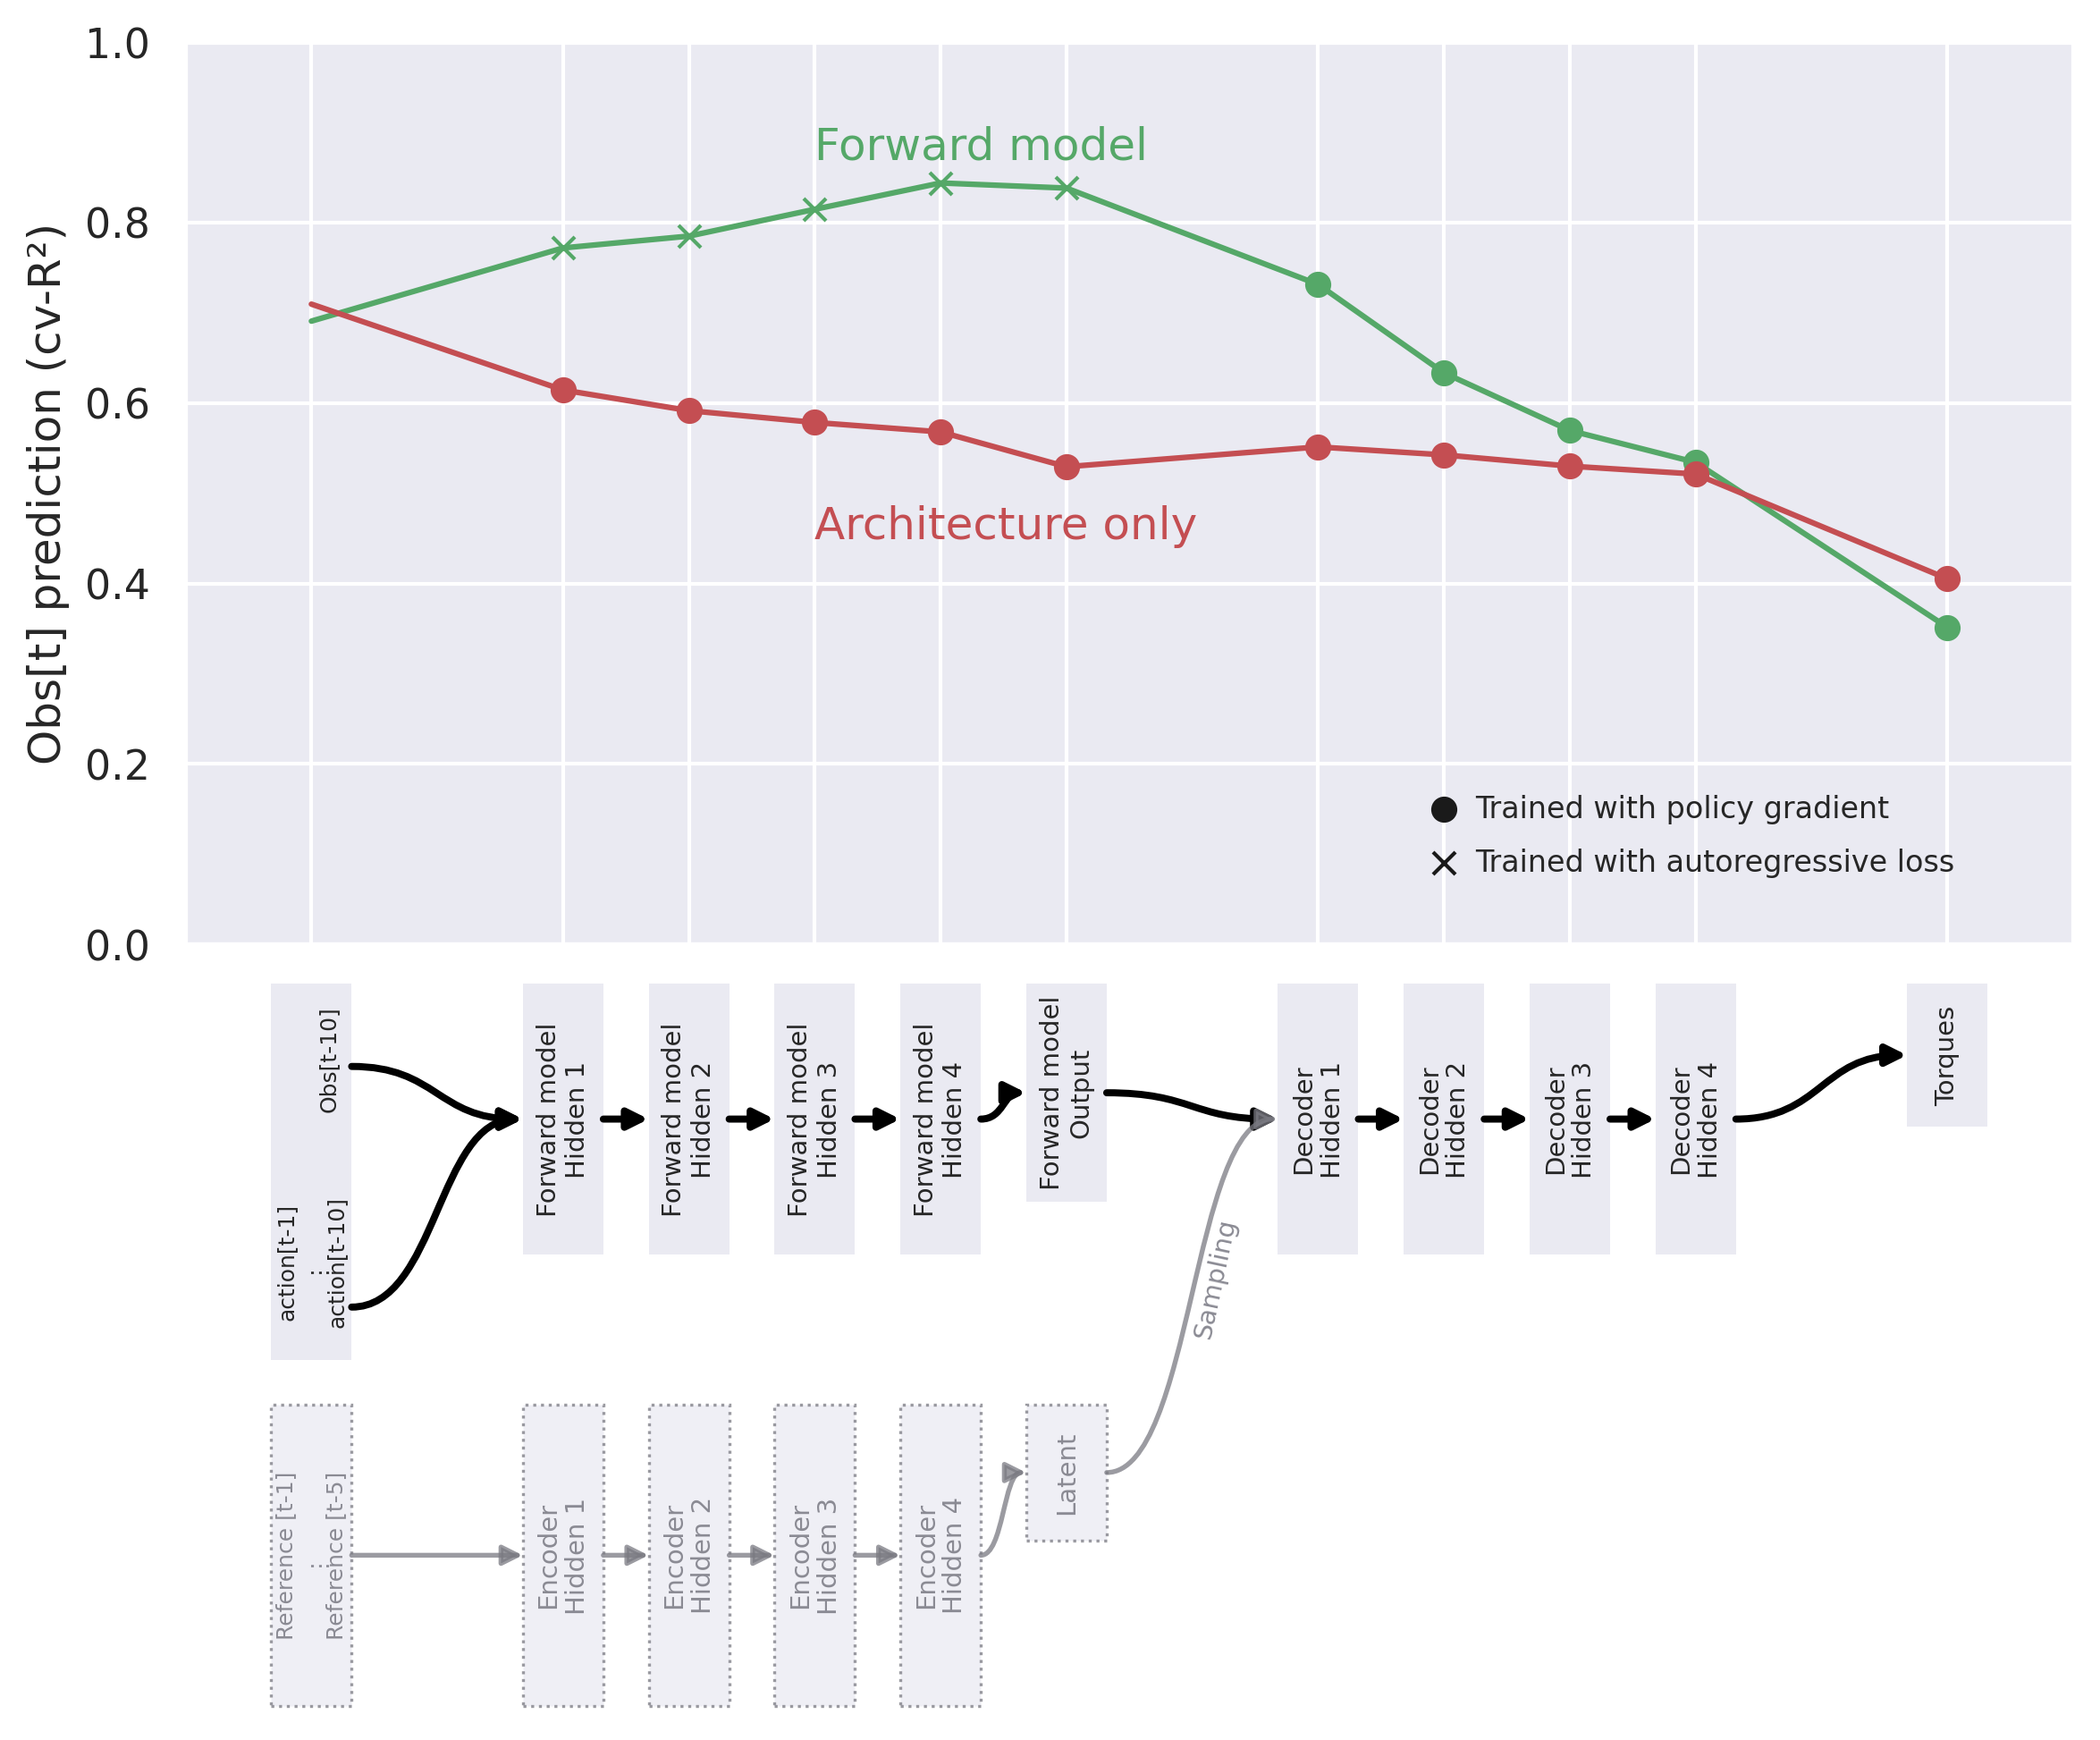

In [378]:
df = data["probe"]
df = df[(df.delay_k == 10) & (df.target == "proprio")]
df = df[(df.wandb_id != "cgs8q5gj") & (df.probe != "layer::3/action/1/decoder/4")]
df = df[df.pathway == "actor"]
df = df[df.budget == 6e8]
expl = expl_k10 = df[df.arm=="explicit"]
impl = impl_k10 = df[df.arm=="implicit"]
fig, (ax, arch) = nd.figure_with_diagram(figsize=(8, 7), height=0.45, dpi=300)
ax.plot(xs, expl.test_r2, color="C2")
ax.plot(xs[6:], expl.test_r2.iloc[6:], 'o', color="C2")
ax.plot(xs[1:6], expl.test_r2.iloc[1:6], 'x', color="C2")
ax.plot(xs, impl.test_r2, color="C3")
ax.plot(xs[1:], impl.test_r2.iloc[1:], 'o', color="C3")
ax.set_xticks(xs)
ax.set_ylim(0, 1)
ax.set_ylabel("Obs[t] prediction (cv-R²)")
ax.plot(8, 0.15, 'o', color='k')
ax.text(8.25, 0.15, "Trained with policy gradient", va="center", fontsize=8)
ax.plot(8, 0.09, 'x', color='k')
ax.text(8.25, 0.09, "Trained with autoregressive loss", va="center", fontsize=8)
ax.text(3, 0.87, "Forward model", color="C2")
ax.text(3, 0.45, "Architecture only", color="C3")
nd.draw(arch, notes=False)
plt.show()

In [ ]:
import dataclasses


Diagram(boxes=(Box(key='input', x=-1, label='action[t-1]\n⋮\naction[20]', height=0.5, top=0.97, style=Style(box_fill='#EAEAF2', text_color='#262626', line_color='#000000', edge_color='none', edge_style='solid', edge_width=0.0, line_width=1.9, font_size=7.0, alpha=1.0), label_y=0.26, label_x=0.5, extras=(('Obs[20]', 0.72, 0.8),), tick_label='input\n(delayed +\nefference)', font_size=6.0), Box(key='pred1', x=1, label='Forward model\nHidden 1', height=0.36, top=0.97, style=Style(box_fill='#EAEAF2', text_color='#262626', line_color='#000000', edge_color='none', edge_style='solid', edge_width=0.0, line_width=1.9, font_size=7.0, alpha=1.0), label_y=0.5, label_x=0.5, extras=(), tick_label='pred 1', font_size=None), Box(key='pred2', x=2, label='Forward model\nHidden 2', height=0.36, top=0.97, style=Style(box_fill='#EAEAF2', text_color='#262626', line_color='#000000', edge_color='none', edge_style='solid', edge_width=0.0, line_width=1.9, font_size=7.0, alpha=1.0), label_y=0.5, label_x=0.5, extr

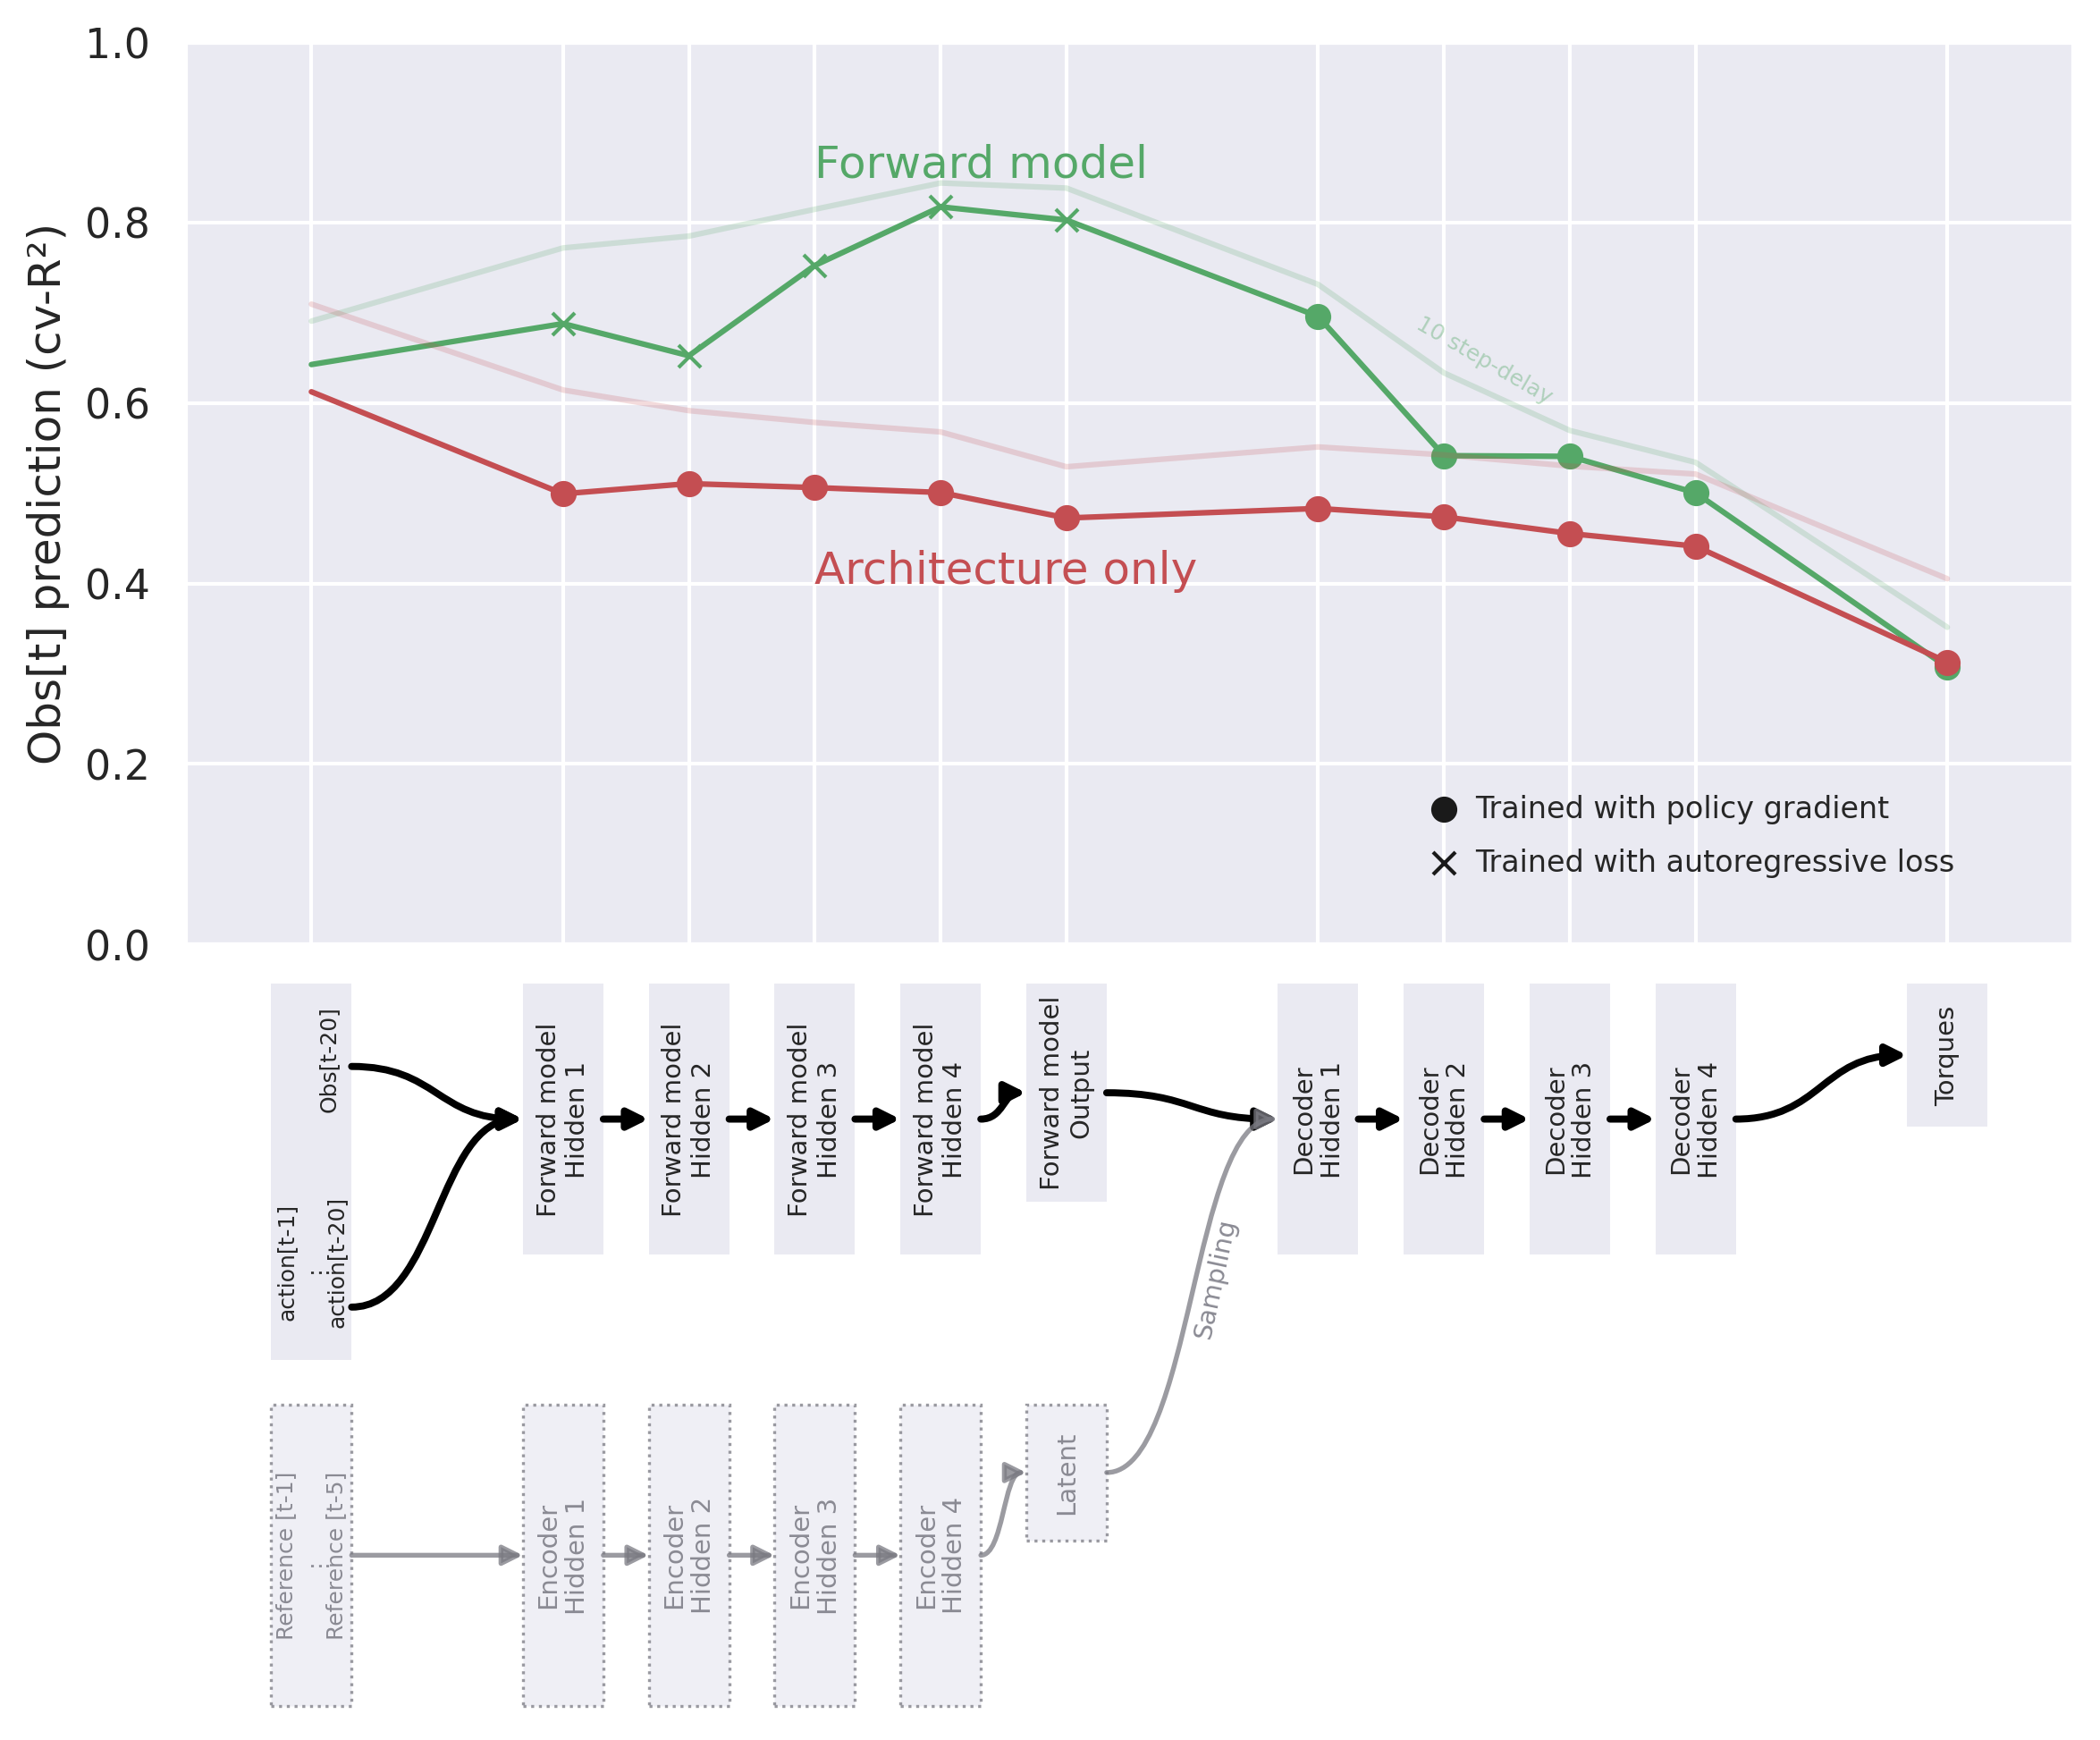

In [407]:
df = data["probe"]
df = df[(df.delay_k == 20) & (df.target == "proprio")]
df = df[(df.wandb_id != "cgs8q5gj") & (df.probe != "layer::3/action/1/decoder/4")]
df = df[df.pathway == "actor"]
df = df[df.budget == 6e8]
expl = df[df.arm=="explicit"]
impl = df[df.arm=="implicit"]
fig, (ax, arch) = nd.figure_with_diagram(figsize=(8, 7), height=0.45, dpi=300)
ax.plot(xs, expl.test_r2, color="C2")
ax.plot(xs[6:], expl.test_r2.iloc[6:], 'o', color="C2")
ax.plot(xs[1:6], expl.test_r2.iloc[1:6], 'x', color="C2")
ax.plot(xs, impl.test_r2, color="C3")
ax.plot(xs[1:], impl.test_r2.iloc[1:], 'o', color="C3")

ax.plot(xs, expl_k10.test_r2, color="C2", alpha=0.2)
ax.plot(xs, impl_k10.test_r2, color="C3", alpha=0.2)

ax.set_xticks(xs)
ax.set_ylim(0, 1)
ax.set_ylabel("Obs[t] prediction (cv-R²)")
ax.plot(8, 0.15, 'o', color='k')
ax.text(8.25, 0.15, "Trained with policy gradient", va="center", fontsize=8)
ax.plot(8, 0.09, 'x', color='k')
ax.text(8.25, 0.09, "Trained with autoregressive loss", va="center", fontsize=8)
ax.text(3, 0.85, "Forward model", color="C2")
ax.text(3, 0.4, "Architecture only", color="C3")
ax.text(7.75, 0.6, "10 step-delay", color="C2", fontsize=6, rotation=-30, alpha=.4)
diag = dataclasses.replace(nd.DEFAULT_DIAGRAM, boxes = tuple(nd._actor_boxes("t-20") + nd._encoder_boxes()))
nd.draw(arch, diag, notes=False)
plt.show()

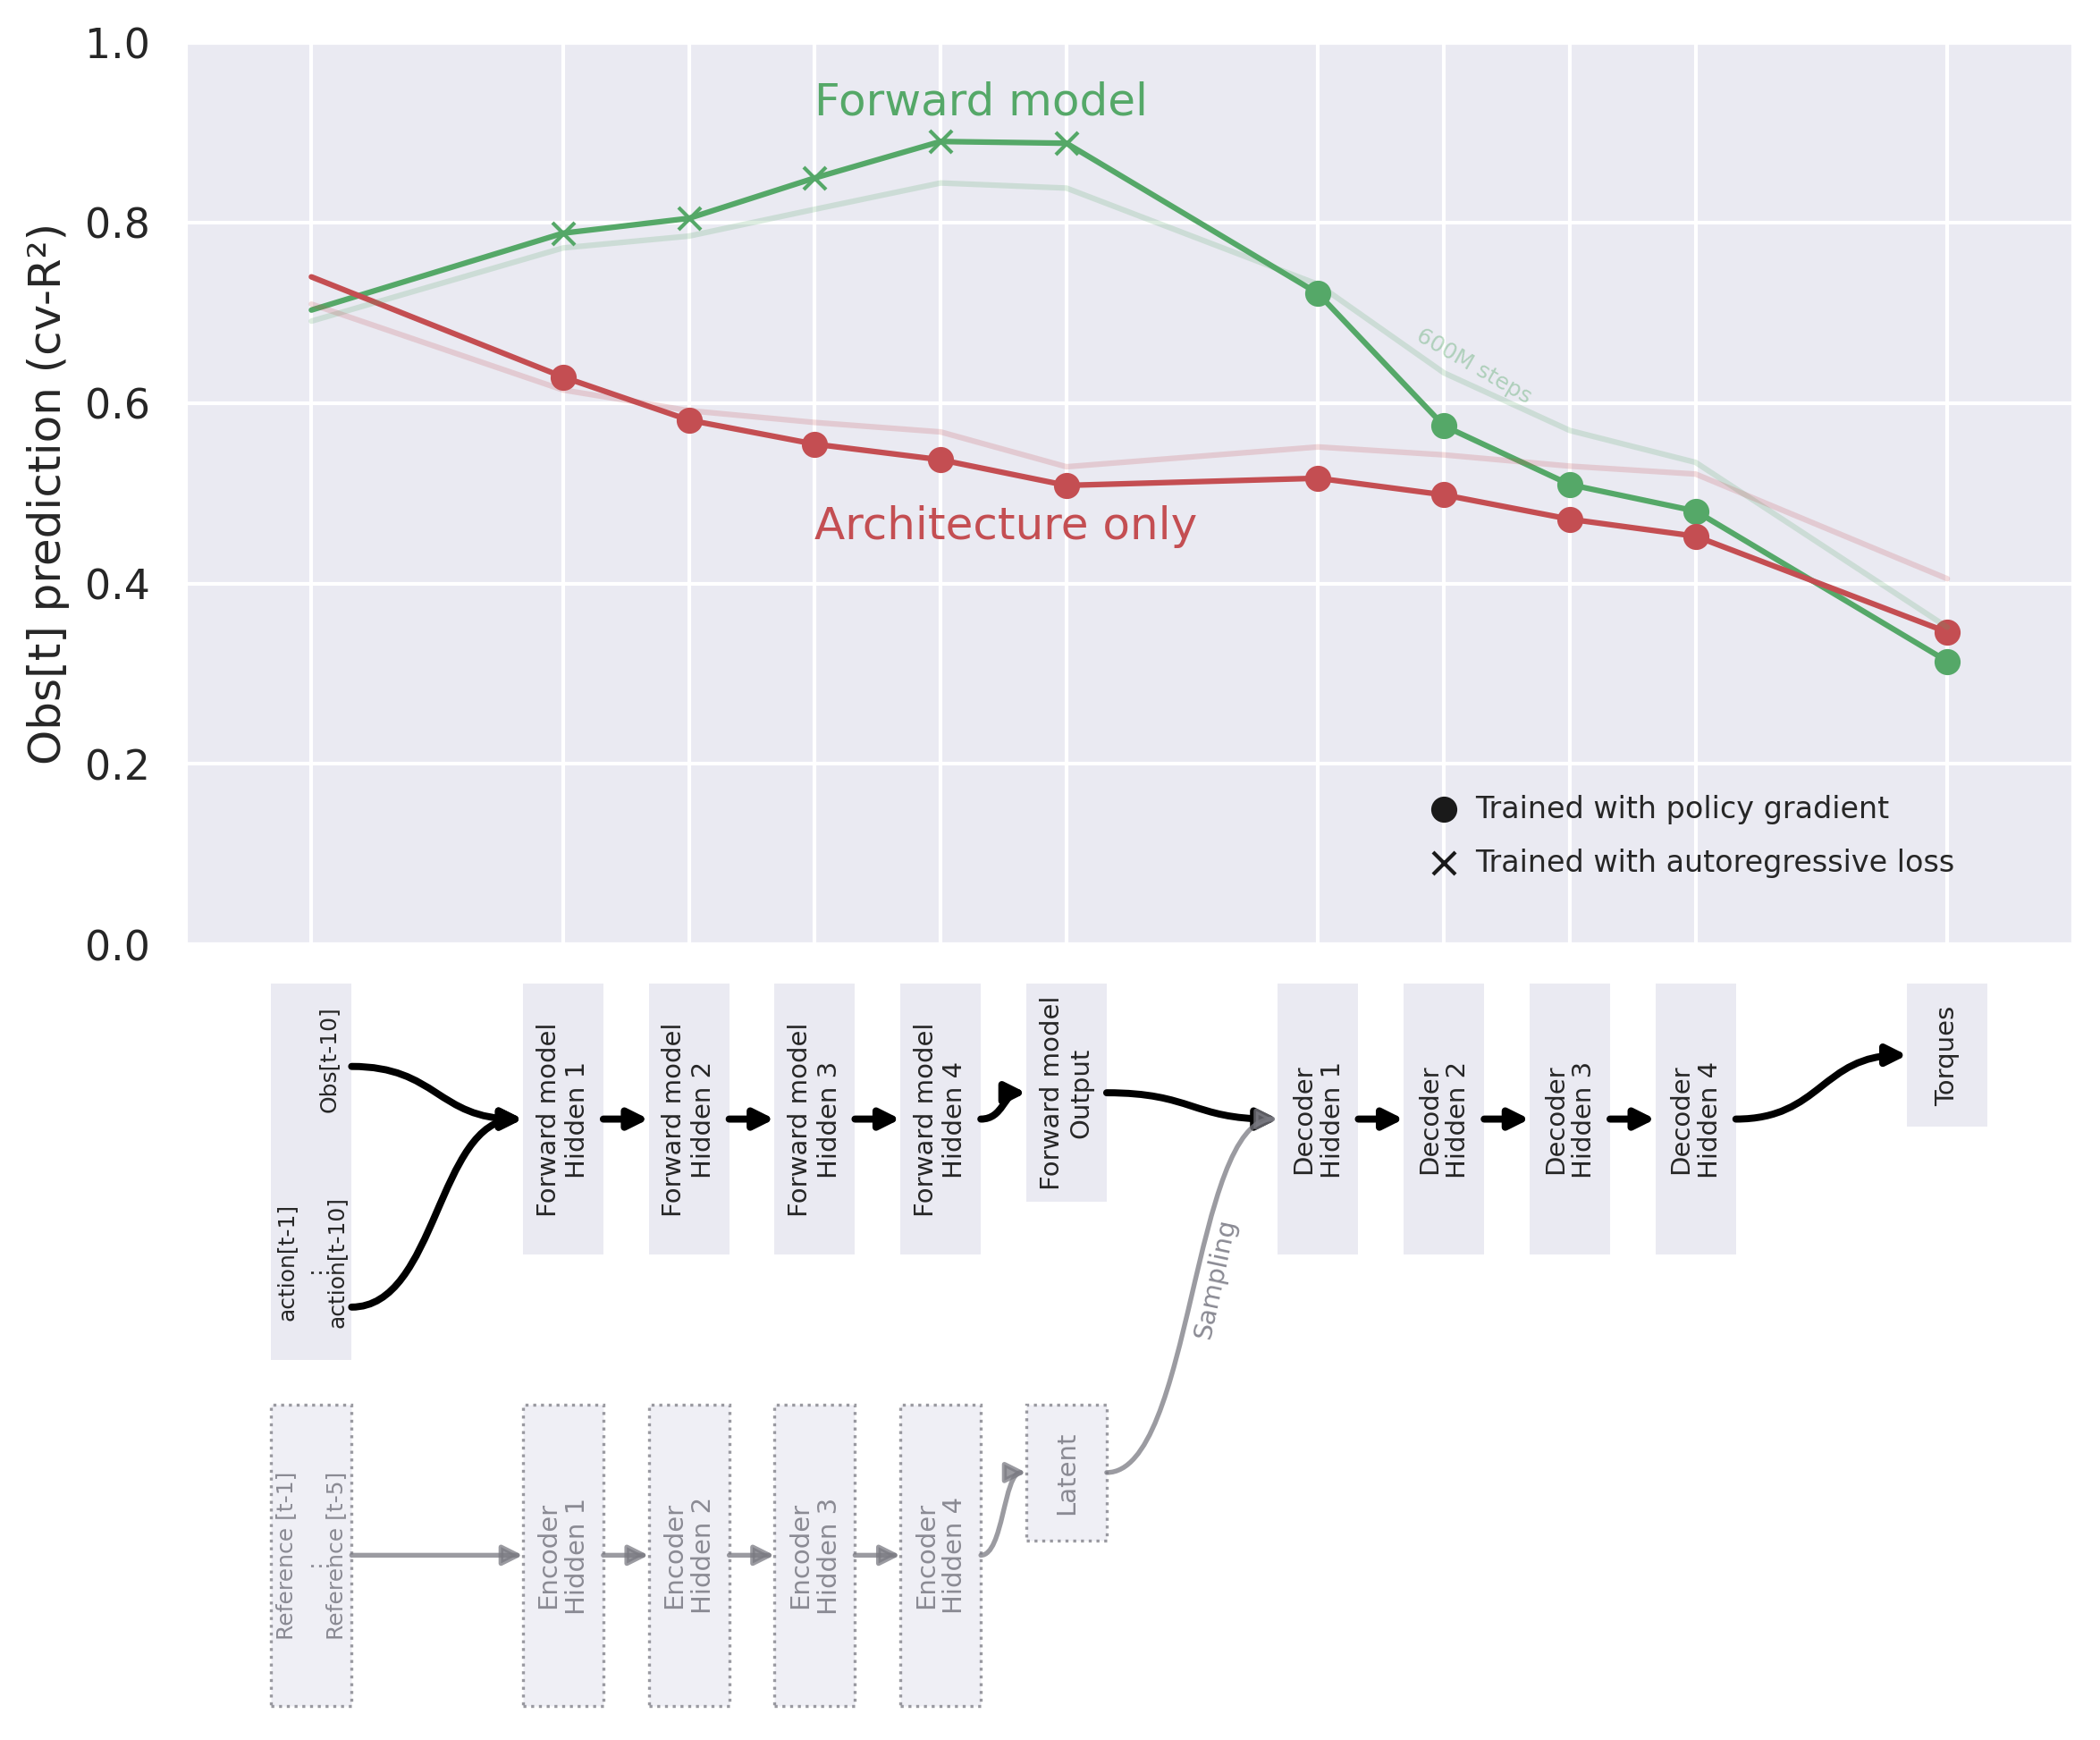

In [408]:
df = data["probe"]
df = df[(df.delay_k == 10) & (df.target == "proprio")]
df = df[(df.wandb_id != "cgs8q5gj") & (df.probe != "layer::3/action/1/decoder/4")]
df = df[df.pathway == "actor"]
df = df[df.budget == 2e9]
expl = df[df.arm=="explicit"]
impl = df[df.arm=="implicit"]
fig, (ax, arch) = nd.figure_with_diagram(figsize=(8, 7), height=0.45, dpi=300)
ax.plot(xs, expl.test_r2, color="C2")
ax.plot(xs[6:], expl.test_r2.iloc[6:], 'o', color="C2")
ax.plot(xs[1:6], expl.test_r2.iloc[1:6], 'x', color="C2")
ax.plot(xs, impl.test_r2, color="C3")
ax.plot(xs[1:], impl.test_r2.iloc[1:], 'o', color="C3")

ax.plot(xs, expl_k10.test_r2, color="C2", alpha=0.2)
ax.plot(xs, impl_k10.test_r2, color="C3", alpha=0.2)

ax.set_xticks(xs)
ax.set_ylim(0, 1)
ax.set_ylabel("Obs[t] prediction (cv-R²)")
ax.plot(8, 0.15, 'o', color='k')
ax.text(8.25, 0.15, "Trained with policy gradient", va="center", fontsize=8)
ax.plot(8, 0.09, 'x', color='k')
ax.text(8.25, 0.09, "Trained with autoregressive loss", va="center", fontsize=8)
ax.text(3, 0.92, "Forward model", color="C2")
ax.text(3, 0.45, "Architecture only", color="C3")
ax.text(7.75, 0.6, "600M steps", color="C2", fontsize=6, rotation=-30, alpha=.4)
diag = dataclasses.replace(nd.DEFAULT_DIAGRAM, boxes = tuple(nd._actor_boxes("t-10") + nd._encoder_boxes()))
nd.draw(arch, diag, notes=False)
plt.show()

In [8]:
curves = data["curves"]
control = curves[(curves["condition"] == "encdec") & (curves["delay_k"] == 10)]
nointent = curves[(curves["condition"] == "ablate_intention") & (curves["delay_k"] == 10)]
noproprio = curves[(curves["condition"] == "ablate_proprioception") & (curves["delay_k"] == 10)]
noefference = curves[(curves["condition"] == "ablate_efference") & (curves["delay_k"] == 10)]

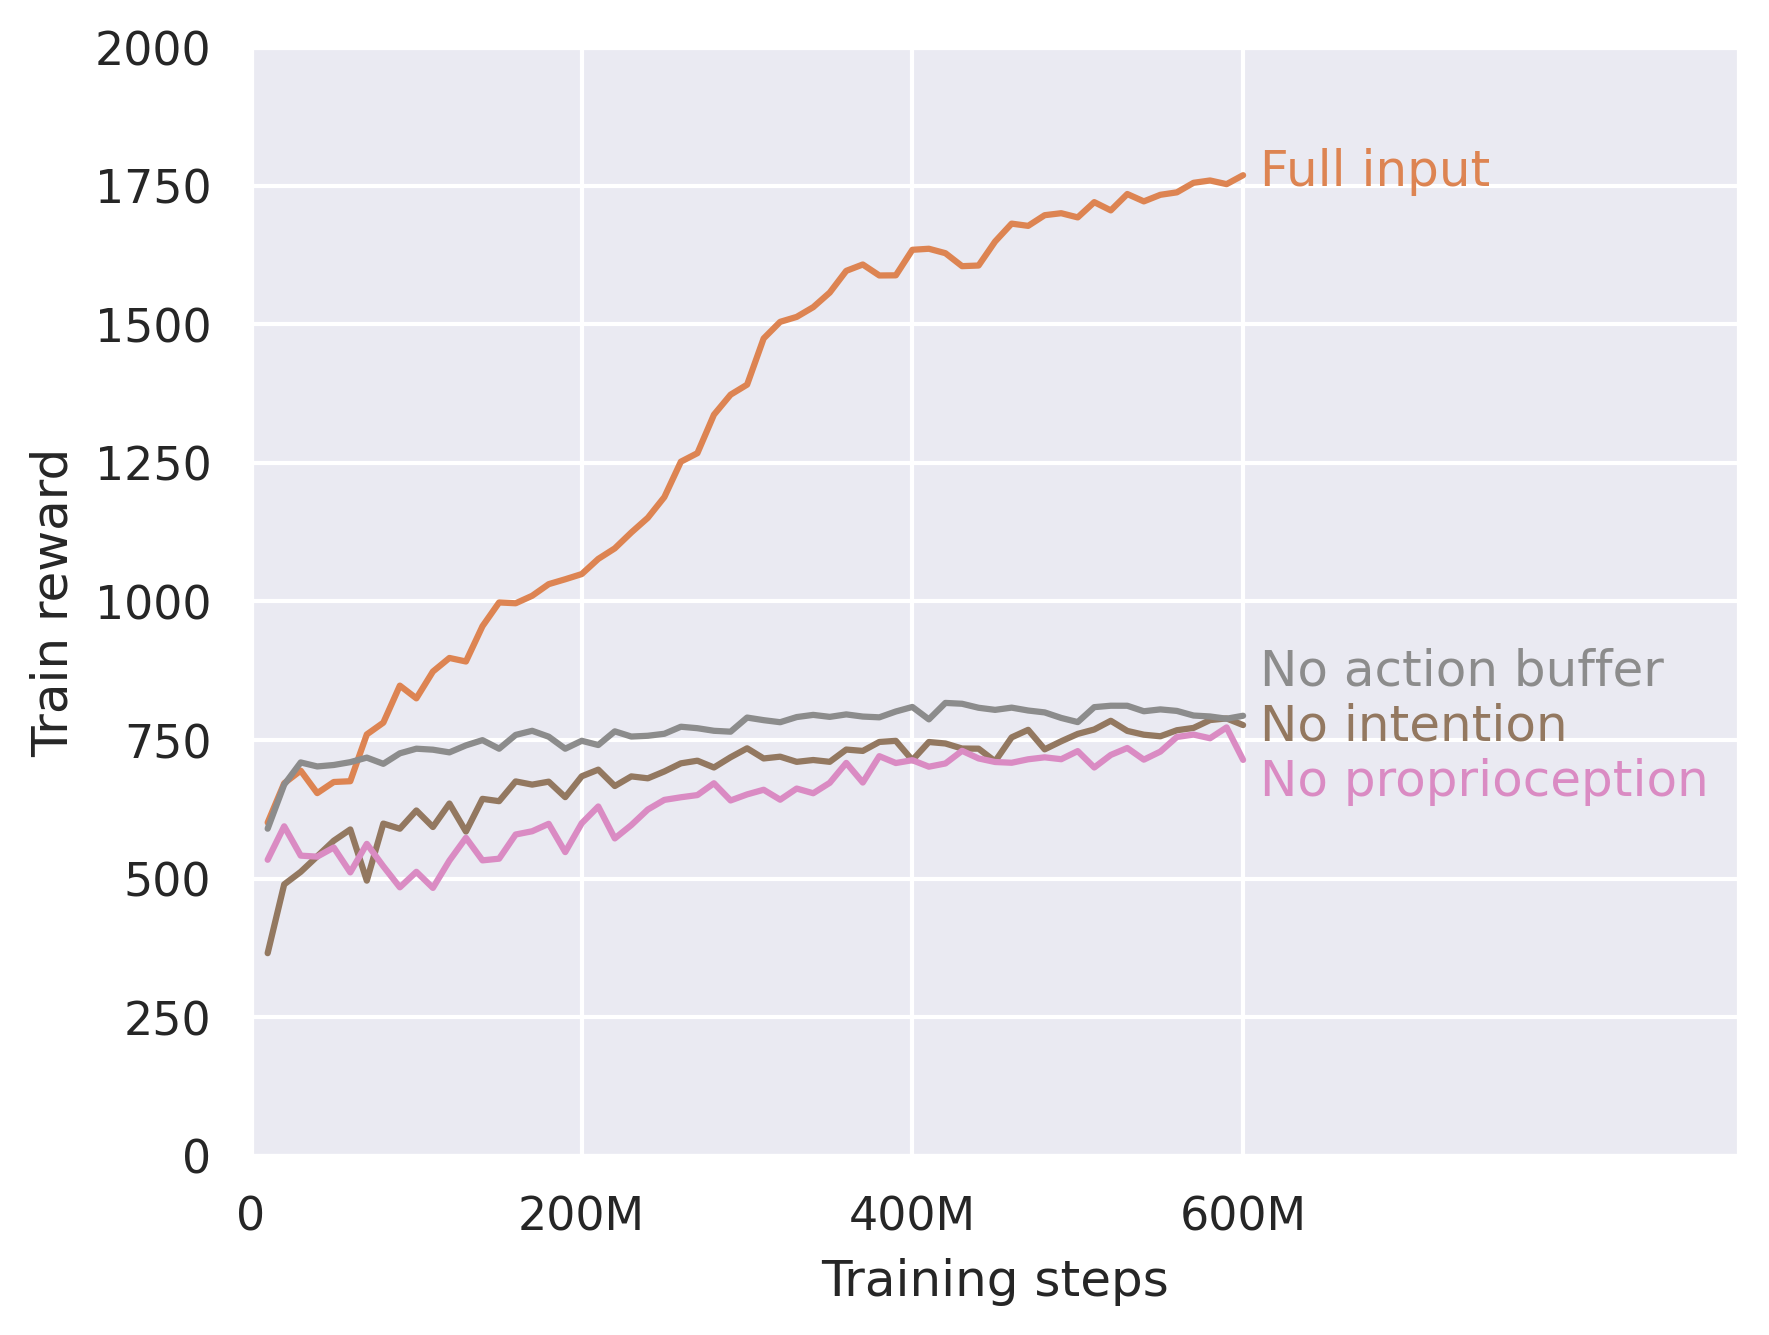

In [20]:
plt.figure(dpi=300)
plt.plot(control.step, control.reward_mean, color="C1")
plt.plot(nointent.step, nointent.reward_mean, color="C5")
plt.plot(noproprio.step, noproprio.reward_mean, color="C6")
plt.plot(noefference.step, noefference.reward_mean, color="C7")
plt.text(6.1e8, 1750, "Full input", color="C1")
plt.text(6.1e8, 750, "No intention", color="C5")
plt.text(6.1e8, 650, "No proprioception", color="C6")
plt.text(6.1e8, 850, "No action buffer", color="C7")
plt.ylim(0, 2000)
plt.xlim(0, 9e8)
plt.ylabel("Train reward")
plt.xlabel("Training steps")
plt.xticks([0,2e8,4e8,6e8], ["0", "200M", "400M", "600M"])
plt.show()

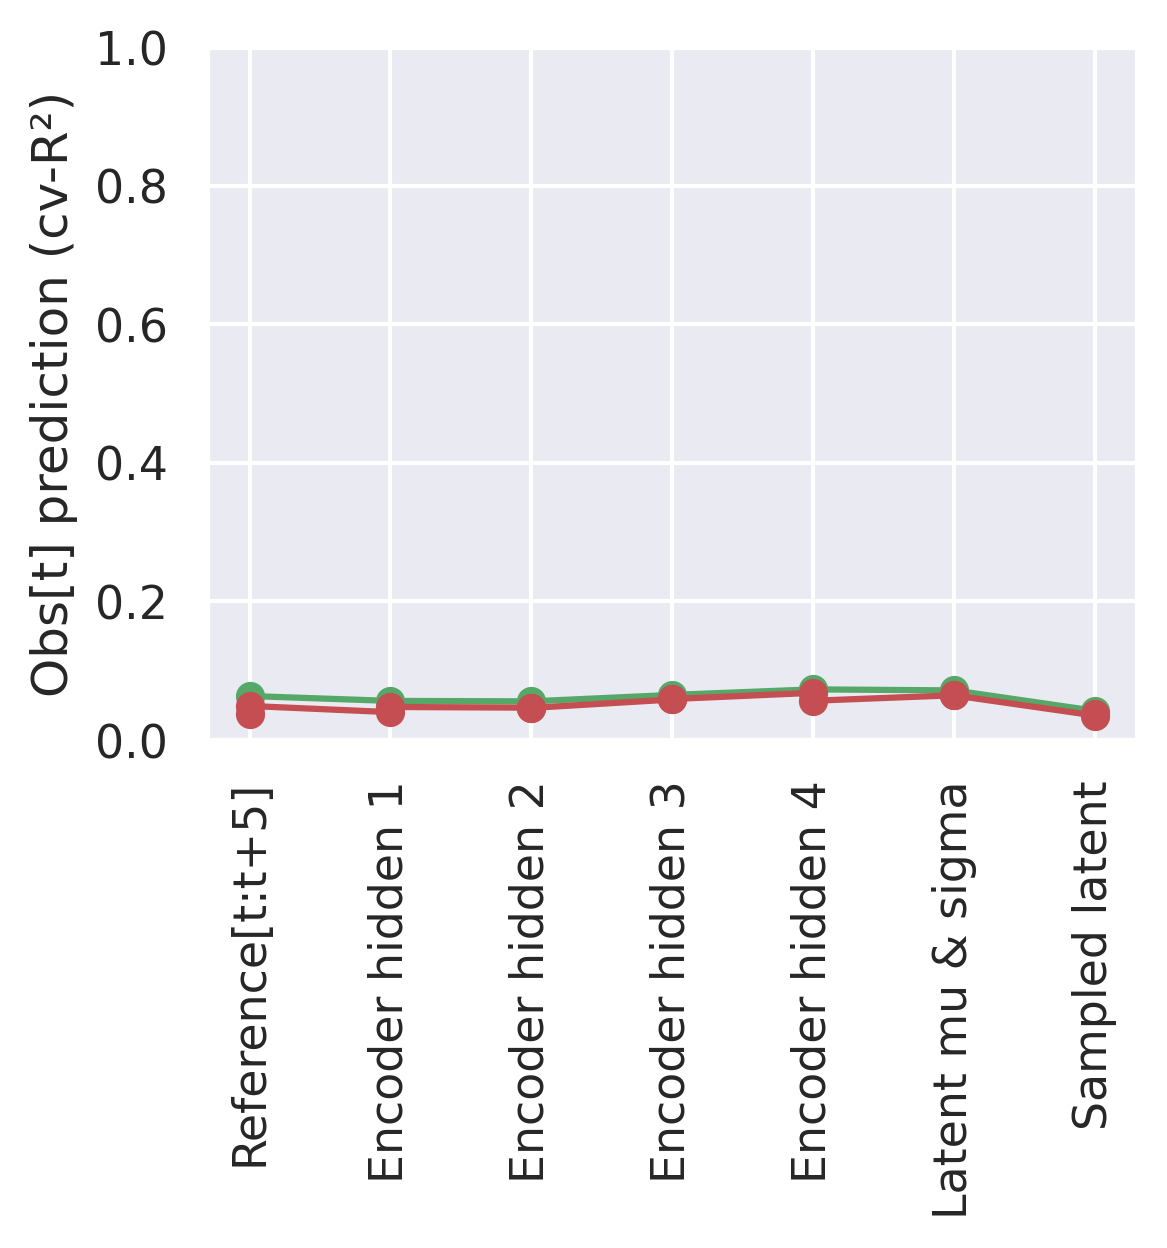

In [39]:
plt.figure(figsize=(4,3), dpi=300)
probe = data["probe"]
probe = probe[(probe.delay_k == 10) & (probe.target == "proprio")]
probe = probe[probe.pathway == "encoder"]
expl = probe[probe.condition == "expfm"]
impl = probe[probe.condition == "pgfm"]
plt.plot(expl.stage_index, expl.test_r2, '-o', color="C2")
plt.plot(impl.stage_index, impl.test_r2, '-o', color="C3")
plt.ylim(0, 1)
plt.ylabel("Obs[t] prediction (cv-R²)")
plt.xticks(range(7), ["Reference[t:t+5]", "Encoder hidden 1", "Encoder hidden 2", "Encoder hidden 3",
                      "Encoder hidden 4", "Latent mu & sigma", "Sampled latent"], rotation=90)
plt.show()


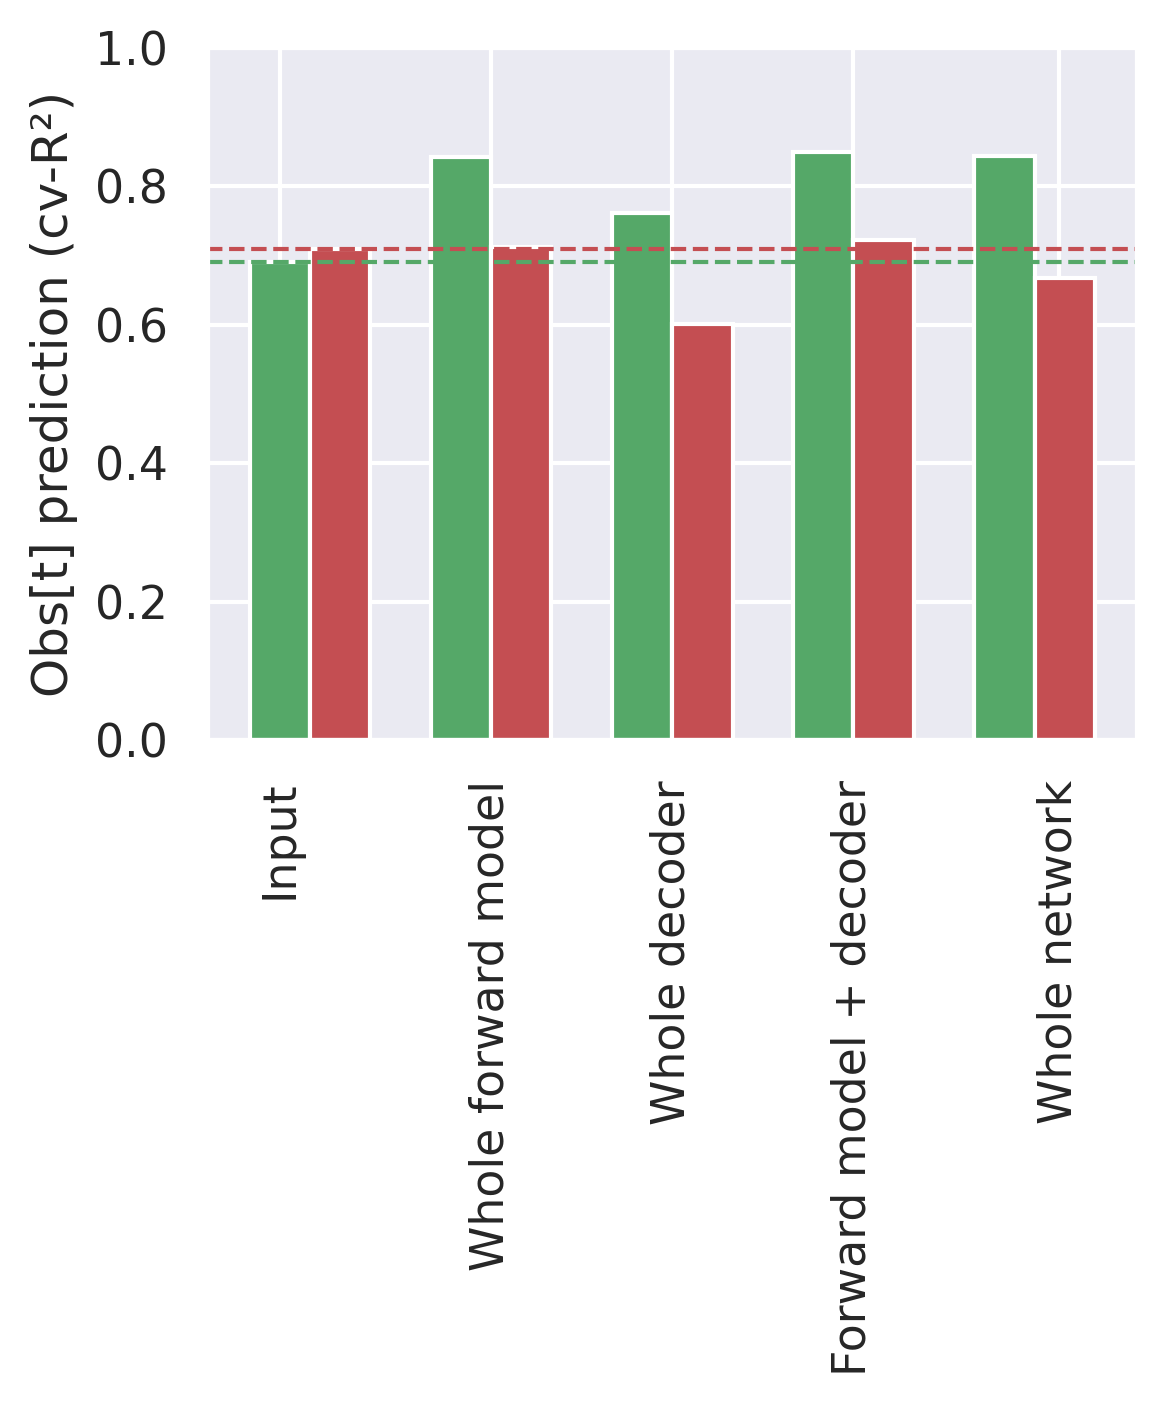

In [72]:
plt.figure(figsize=(4,3), dpi=300)
probe_groups = data["groups"]
probe_groups = probe_groups[(probe_groups.delay_k == 10) & (probe_groups.target == "proprio")]
probe_groups = probe_groups[(probe_groups.wandb_id != "cgs8q5gj")]
probe_groups = probe_groups[(probe_groups.budget == 6e8)]
x_pos = pd.Series({"input": -3, "forward_model": 0, "decoder": 3,
                   "fm_plus_decoder": 6, "whole_network": 9}, name="xpos")
probe_groups = probe_groups.join(x_pos, how="right", on="group")

expl = probe_groups[probe_groups.condition == "expfm"]
impl = probe_groups[probe_groups.condition == "pgfm"]
plt.bar(expl.xpos, expl.test_r2, 1, color="C2")
plt.bar(impl.xpos+1, impl.test_r2, 1, color="C3")
plt.xticks([-3, 0.5, 3.5, 6.5, 9.9], ["Input", "Whole forward model", "Whole decoder", "Forward model + decoder", "Whole network"], rotation=90)
plt.ylim(0, 1)
plt.ylabel("Obs[t] prediction (cv-R²)")
plt.axhline(expl.test_r2.iloc[0], color="C2", ls="--", lw=1)
plt.axhline(impl.test_r2.iloc[0], color="C3", ls="--", lw=1)

In [53]:
probe_groups
#probe_groups[probe_groups.group == "decoder"][["run_name", "wandb_id", "delay_k", "step", "condition", "arm", "budget"]]

,run_name,delay_k,efference_length,step,network_class,dataset,decode_seed,decode_version,group_version,frac_valid,...,group,n_layers,target,target_degenerate,test_r2,val_r2,lambda,n_train,n_test,n_features
8,RodentForwardModel_delay10_eff10-20260811-174250,10,10,600064000,RodentForwardModel,old_eval,0,1,1,0.842064,...,decoder,5,proprio,False,0.761451,0.760951,1000.0,50264,21175,2124
9,RodentForwardModel_delay10_eff10-20260811-174250,10,10,600064000,RodentForwardModel,old_eval,0,1,1,0.842064,...,encoder,7,proprio,False,0.102954,0.085333,100000.0,50264,21175,2784
10,RodentForwardModel_delay10_eff10-20260811-174250,10,10,600064000,RodentForwardModel,old_eval,0,1,1,0.842064,...,fm_plus_decoder,10,proprio,False,0.848780,0.845630,1000.0,50264,21175,4449
11,RodentForwardModel_delay10_eff10-20260811-174250,10,10,600064000,RodentForwardModel,old_eval,0,1,1,0.842064,...,forward_model,5,proprio,False,0.842134,0.843605,10.0,50264,21175,2325
12,RodentForwardModel_delay10_eff10-20260811-174250,10,10,600064000,RodentForwardModel,old_eval,0,1,1,0.842064,...,input,1,proprio,False,0.690712,0.644447,100.0,50264,21175,657
13,RodentForwardModel_delay10_eff10-20260811-174250,10,10,600064000,RodentForwardModel,old_eval,0,1,1,0.842064,...,latent_z,1,proprio,False,0.040880,0.036915,10000.0,50264,21175,32
14,RodentForwardModel_delay10_eff10-20260811-174250,10,10,600064000,RodentForwardModel,old_eval,0,1,1,0.842064,...,p_hat,1,proprio,False,0.838142,0.834023,1000.0,50264,21175,277
15,RodentForwardModel_delay10_eff10-20260811-174250,10,10,600064000,RodentForwardModel,old_eval,0,1,1,0.842064,...,whole_network,17,proprio,False,0.843133,0.827541,10000.0,50264,21175,7233
65,RodentForwardModel_delay10_eff10_nodetach-2026...,10,10,600064000,RodentForwardModel,old_eval,0,1,1,0.817464,...,decoder,5,proprio,False,0.600506,0.581366,1000.0,48403,20949,2124
67,RodentForwardModel_delay10_eff10_nodetach-2026...,10,10,600064000,RodentForwardModel,old_eval,0,1,1,0.817464,...,encoder,7,proprio,False,0.087584,0.074685,100000.0,48403,20949,2784


In [4]:
rec_data = pd.read_csv("analysis/recurrent-architectures/data.csv")
rec_data.loc[rec_data.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis

/tmp/ipykernel_6027/2428635591.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rec_data.loc[rec_data.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis


In [5]:
lstm_limited_eff = rec_data[(rec_data.condition == "lstm") & (rec_data.efference_length == 1) & (rec_data.rollout_length == 60)]
lstm_full_eff = rec_data[(rec_data.condition == "lstm") & (rec_data.efference_length == rec_data.delay_k) & (rec_data.rollout_length == 60)]
ff_limited_eff = rec_data[(rec_data.condition == "feedforward") & (rec_data.efference_length == 1) & (rec_data.rollout_length == 60)]
ff_full_eff = rec_data[(rec_data.condition == "feedforward") & (rec_data.efference_length == rec_data.delay_k) & (rec_data.rollout_length == 20)]

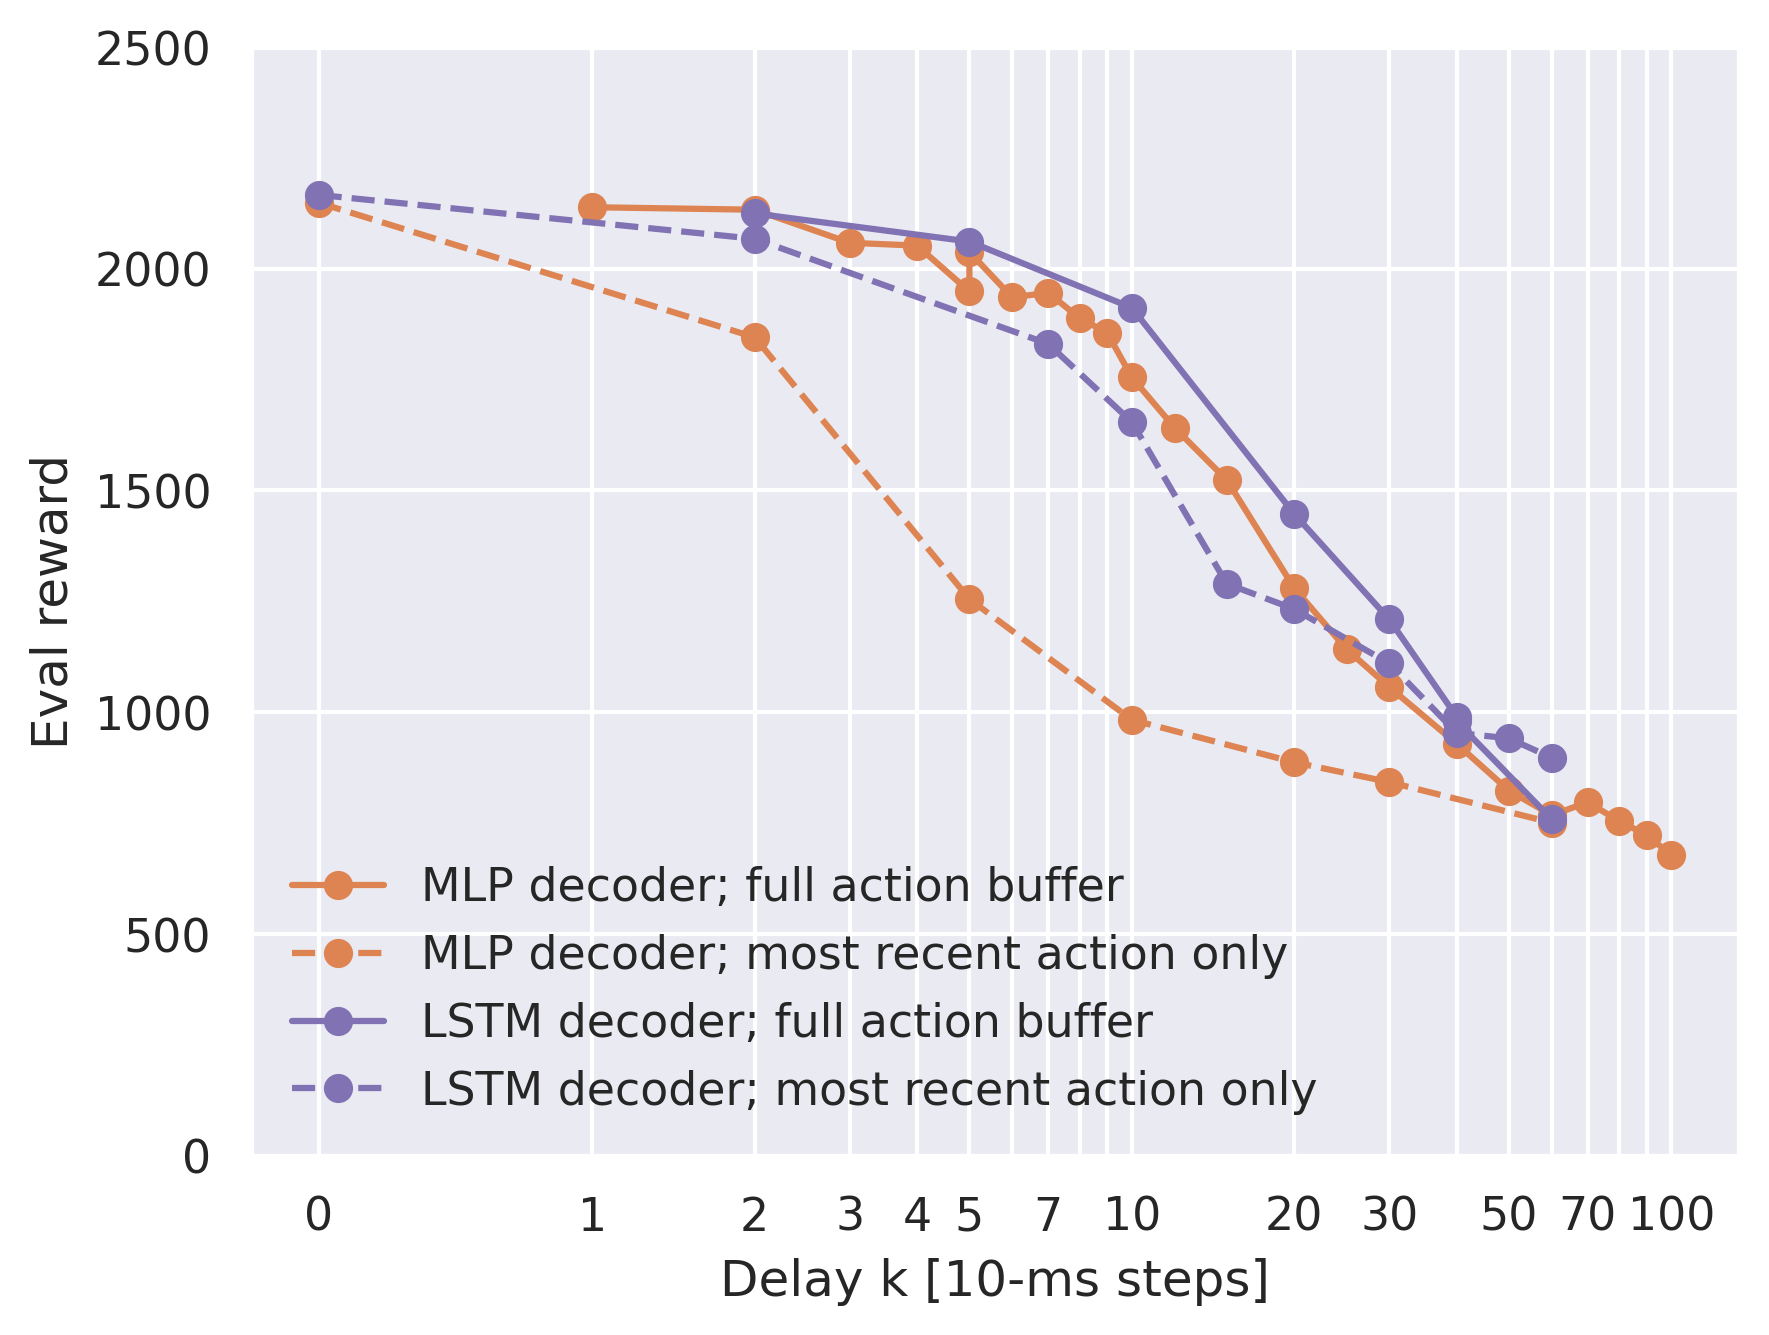

In [18]:
plt.figure(dpi=300)
plt.semilogx(ff_full_eff.delay_k, ff_full_eff.old_eval_reward, '-o', color="C1", label="MLP decoder; full action buffer")
plt.semilogx(ff_limited_eff.delay_k, ff_limited_eff.old_eval_reward, '--o', color="C1", label="MLP decoder; most recent action only")
plt.semilogx(lstm_full_eff.delay_k, lstm_full_eff.old_eval_reward, '-o', color="C4", label="LSTM decoder; full action buffer")
plt.semilogx(lstm_limited_eff.delay_k, lstm_limited_eff.old_eval_reward, '--o', color="C4", label="LSTM decoder; most recent action only")
plt.ylim(0, 2500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Eval reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100]
plt.xticks(xticks,xticklabels)
plt.legend(frameon=False)
#plt.text(12, 1400, "LSTM decoder", color="C4", rotation=-45)
plt.show()

In [19]:
rec_data

,condition,wandb_id,wandb_name,git_commit,rollout_length,delay_k,efference_length,eff_ratio,rnn_cell,total_params,actual_step,metric_source,train_reward,old_eval_reward,new_eval_reward,old_eval_lifespan,survived
0,feedforward,9htwlukh,RodentEncDec_delay0_eff0-20260811-075304,ef060b7,20,0,0,NaN,NaN,4125325.0,600064000.0,artifact:eval3ds-n00-6a6b8d4e,2179.364583,2144.981657,11338.058582,484.721893,0.988166
1,feedforward,ame77mw2,RodentEncDec_delay0_eff0-20260824-091609,a3450a9,20,0,0,NaN,NaN,4125325.0,600064000.0,inline_final_eval,2171.727018,2146.214944,10553.797401,484.857988,0.982249
2,feedforward,fcnv7qnl,RodentEncDec_delay0_eff1-20260828-074108,4245ae4,60,0,1,NaN,NaN,4144781.0,600145920.0,inline_final_eval,2170.764931,2148.754617,9702.116084,486.763314,0.982249
3,feedforward,17p127fn,RodentEncDec_delay1_eff1-20260811-075237,ef060b7,20,1,1,1.000000,NaN,4144781.0,600064000.0,artifact:eval3ds-n00-6a6b8d4e,2154.152052,2138.641570,9846.615763,486.349112,0.982249
4,feedforward,50kclg6u,RodentEncDec_delay2_eff1-20260828-063332,4245ae4,60,2,1,0.500000,NaN,4144781.0,600145920.0,inline_final_eval,1942.601959,1845.358307,9314.677531,449.982249,0.869822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,lstm,s5ljwe6x,RodentEncDecLSTM_delay60_eff1-20260827-194744,4245ae4,60,60,1,0.016667,lstm,6243981.0,600145920.0,inline_final_eval,955.982131,897.371126,1854.054965,302.656805,0.360947
61,lstm,1scghgg9,RodentEncDecLSTM_delay60_eff60-20260828-140552,4245ae4,60,60,60,1.000000,lstm,7391885.0,600145920.0,inline_final_eval,811.101394,758.895440,1094.587563,274.029586,0.331361
62,rnn,z15cqas5,RodentEncDecRNN_delay5_eff1-20260827-174134,4245ae4,60,5,1,0.200000,rnn,4669581.0,600145920.0,inline_final_eval,1932.755266,1856.910118,8789.298159,453.928994,0.887574
63,rnn,8nkb8v35,RodentEncDecRNN_delay10_eff10-20260827-174134,4245ae4,60,10,10,1.000000,rnn,4844685.0,600145920.0,inline_final_eval,1654.186148,1489.780691,6465.295098,379.159763,0.627219
